In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns

In [45]:
df = pd.read_csv(r"H:\DALearning\PythonCodes\PythonLearning\Z-Projects (DA)\Election-2082\2. data_wrangling\2.2 data_assessing_and_cleaning\cleaned_data.csv")

In [46]:
df.head()

,Unnamed: 0,candidate_id,candidate,age,party,party_id,votes,gender,is_winner,father,...,spouse,experience,province,district,constituency,votes_cast,total_voters,education_category,latitude,longitude
0,0,339933,Khitiz Thebe,38,Nepal Communist Party (Ekikrit Marxbadi Leninb...,2598.0,13962,M,True,भुपेन्द्र थेबे,...,NaN,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Bachelor's Degree,27.35,87.6667
1,1,341131,Gajendra Prasad Tumyang Limbu,46,Nepali Congress,2583.0,11711,M,False,Purna Bahadur Limbu,...,Radhika Lingden Tumyang,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Bachelor's Degree,27.35,87.6667
2,2,339610,Khel Prasad Buda Chhetri,50,Nepali Communist Party,2557.0,6775,M,False,शम्सेर बहादुर बुडाक्षेत्री,...,कुमारी बुडाक्षेत्री,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Higher Secondary / Intermediate (10+2 / PCL),27.35,87.6667
3,3,340005,Santosh Rai,49,Shram Sanskriti Party,2501.0,5209,M,False,Bal Bahadur Rai,...,Sita Rai,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Basic Education (Up to Grade 8),27.35,87.6667
4,4,340459,Birendra Shrestha,55,Rastriya Swatantra Party,2528.0,4155,M,False,Tek Bahadur Shrestha,...,Manolak Wuphashree Shrestha,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Bachelor's Degree,27.35,87.6667


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3406 entries, 0 to 3405
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          3406 non-null   int64  
 1   candidate_id        3406 non-null   int64  
 2   candidate           3406 non-null   object 
 3   age                 3406 non-null   int64  
 4   party               3406 non-null   object 
 5   party_id            2263 non-null   float64
 6   votes               3406 non-null   int64  
 7   gender              3406 non-null   object 
 8   is_winner           3406 non-null   bool   
 9   father              3405 non-null   object 
 10  qualification       2762 non-null   object 
 11  institution         1769 non-null   object 
 12  address             3406 non-null   object 
 13  spouse              2595 non-null   object 
 14  experience          1083 non-null   object 
 15  province            3406 non-null   object 
 16  distri

In [48]:
df.drop(columns=['Unnamed: 0'], inplace=True)

- *I removed the `Unnamed: 0` column because it was automatically generated when the dataset was exported with the index included.*

#### **My goal**

<font color="gold">*The objective of this project is to develop a **predictive model** that estimates whether a candidate is likely to win the election or predicts the number of votes they are expected to receive based on the available data. This objective guides the data preprocessing, feature engineering, and exploratory data analysis workflows throughout the project.*</font>

# EDA **Steps**:

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3406 entries, 0 to 3405
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   candidate_id        3406 non-null   int64  
 1   candidate           3406 non-null   object 
 2   age                 3406 non-null   int64  
 3   party               3406 non-null   object 
 4   party_id            2263 non-null   float64
 5   votes               3406 non-null   int64  
 6   gender              3406 non-null   object 
 7   is_winner           3406 non-null   bool   
 8   father              3405 non-null   object 
 9   qualification       2762 non-null   object 
 10  institution         1769 non-null   object 
 11  address             3406 non-null   object 
 12  spouse              2595 non-null   object 
 13  experience          1083 non-null   object 
 14  province            3406 non-null   object 
 15  district            3406 non-null   object 
 16  consti

## 1. Label Columns

- **Numerical:** `age`, `votes`, `votes_cast`, `total_voters`
- **Categorical:** `party`, `gender`, `education_category`, `constituency`, `province`, `district`, `address`, `is_winner`

> ***Note:** The remaining columns are kept because they help create a dashboard that shows detailed information and makes the analysis easier to understand.*

## 2. **Univariate = one variable**

* **Numerical:** mean, median, histogram, box plot, outliers, skewness
* **Categorical:** frequency, count plot, missing values

### `age` → (num)

In [50]:
df['age'].describe()

count    3406.000000
mean       46.959777
std        11.276963
min        25.000000
25%        39.000000
50%        47.000000
75%        55.000000
max        88.000000
Name: age, dtype: float64

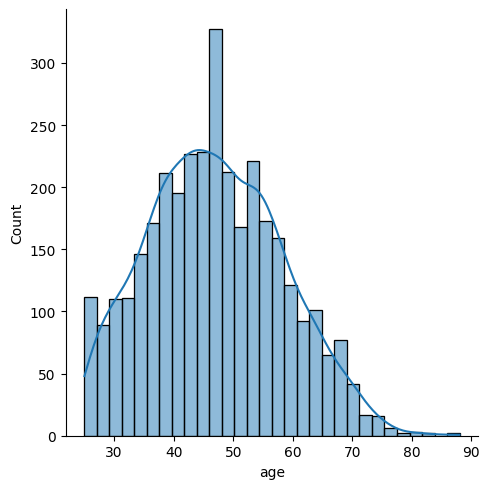

In [51]:
sns.displot(kind='hist', data=df, x='age', kde=True)

- *The age distribution shows that the **40–50 years age group** has the highest frequency, representing the largest proportion of candidates in the dataset.*

In [52]:
df['age'].between(40,50).sum()

np.int64(1189)

In [53]:
df['age'].skew()

np.float64(0.22025297211384096)

- *The data distribution is **relatively close to a normal distribution**, with a **skewness value of 0.20**, suggesting a slight positive skew.*

> ***Note:** Since **0.20 is positive**, it is more accurate to say **"slight positive skew"** rather than simply "close to normal." A skewness between approximately **−0.5 and +0.5** is generally considered approximately symmetric or close to normal.*

<Axes: ylabel='age'>

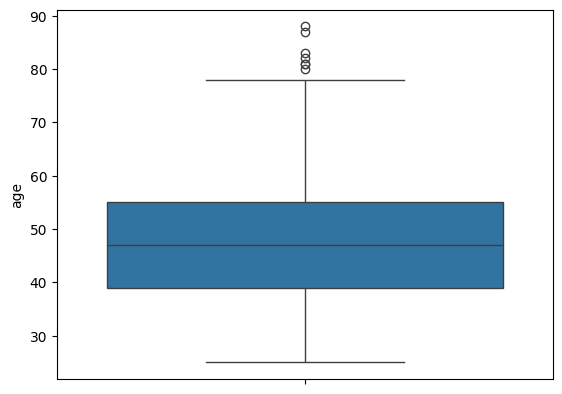

In [54]:
sns.boxplot(df['age'])

- *The boxplot identifies **observations with ages greater than 80** as potential outliers according to the **Interquartile Range (IQR) method**.*

In [55]:
df[df['age'] > 80]

,candidate_id,candidate,age,party,party_id,votes,gender,is_winner,father,qualification,...,spouse,experience,province,district,constituency,votes_cast,total_voters,education_category,latitude,longitude
68,340077,Hiranya Prasad Bhattarai,83,Nepal Majdur Kisan Party,2578.0,23,M,False,Ramakanta Upadhyaya Bhattarai,SLC (पूर्व मध्‍यमा),...,NaN,"कृषि,\nप्राथमिक विद्यालयमा संस्थापक अध्‍यक्ष भ...",Koshi,Jhapa,Jhapa-1,78291,130993,NaN,26.6333,88.0833
984,341515,Prem Bahadur Rana Magar,81,Swatantra,NaN,47,M,False,Karna Singh Rana Magar,साधारण लेखपढ,...,Tulsi Maya Lopchan,NaN,Madhesh,Mahottari,Mahottari-1,63243,105456,Literate / Non-Formal,26.8000,85.8500
1139,341177,Mahindra Raya Yadav,88,Nepali Communist Party,2557.0,8523,M,False,शुभ करण यादव,एस.एल.सी. उतिर्ण,...,ममता देवी यादव,,Madhesh,Sarlahi,Sarlahi-2,72381,123043,Secondary Education (Grade 9-10 / SLC / SEE),26.9167,85.5833
1431,339792,Madan Dev Acharya,87,Swatantra,NaN,9,M,False,Shiv Prasad Acharya,NaN,...,Uma Devi Acharya,NaN,Bagmati,Kathmandu,Kathmandu-4,48689,74150,NaN,27.7333,85.3450
1540,340930,Pancha Kumari Manandhar,82,Swatantra,NaN,69,F,False,Bekha Narayan Manandhar,PHD,...,Hari Narayan Manandhar,NaN,Bagmati,Kathmandu,Kathmandu-9,50670,77745,Doctorate / PhD,27.6900,85.2800
2660,340754,Jay Narayan Kafle,81,Swatantra,NaN,22,M,False,Sashidhar Kafle,साक्षर,...,Vishnu Devi Kafle,NaN,Lumbini,Rupandehi,Rupandehi-5,78825,134426,Literate / Non-Formal,27.4833,83.3000


- *The IQR method classifies **ages above 80** as statistical outliers. However, these observations appear to be **valid** and should not be considered anomalies or errors, as candidates of this age can naturally occur in election data.*

In [56]:
df['age'].isna().sum()

np.int64(0)

### `votes` → (num)

In [57]:
df['votes'].describe()

count     3406.000000
mean      3100.122431
std       7806.744228
min          0.000000
25%         17.000000
50%         87.000000
75%        966.500000
max      68348.000000
Name: votes, dtype: float64

- *There is a substantial difference between the **mean (3,100)** and the **median (87)**, suggesting that the data is heavily skewed. This is reasonable for election data because vote counts depend on factors such as candidate popularity, political parties, and constituency characteristics.*

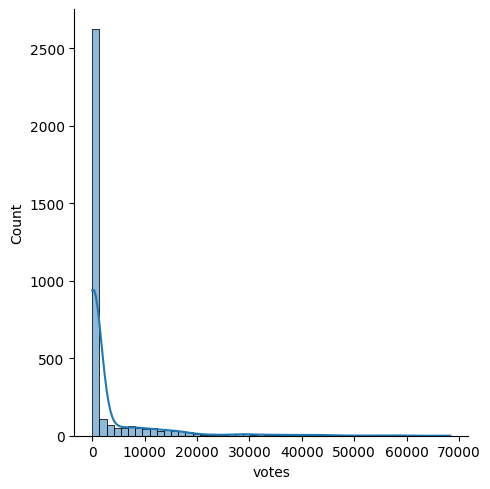

In [58]:
sns.displot(kind='hist', data=df, x='votes', bins=50, kde=True)

- *Most candidates received votes between **0 and 5000**, making this the most frequent vote range.*

In [59]:
df['votes'].skew()

np.float64(3.719976197698429)

- *The distribution does not appear to be normal due to its **strong positive skewness**, where a small number of large values pull the mean far above the median.*

<Axes: ylabel='votes'>

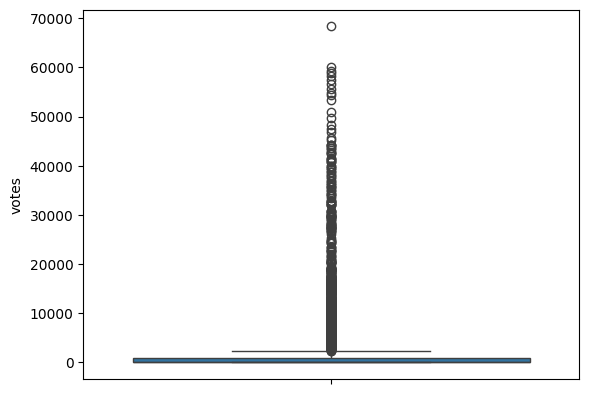

In [60]:
sns.boxplot(df['votes'])

- *The boxplot indicates that votes above **5000** are treated as outliers based on the interquartile range (IQR) method.*

In [61]:
df[df['votes'] > 5000]

,candidate_id,candidate,age,party,party_id,votes,gender,is_winner,father,qualification,...,spouse,experience,province,district,constituency,votes_cast,total_voters,education_category,latitude,longitude
0,339933,Khitiz Thebe,38,Nepal Communist Party (Ekikrit Marxbadi Leninb...,2598.0,13962,M,True,भुपेन्द्र थेबे,स्नातक,...,NaN,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Bachelor's Degree,27.3500,87.6667
1,341131,Gajendra Prasad Tumyang Limbu,46,Nepali Congress,2583.0,11711,M,False,Purna Bahadur Limbu,स्नातक,...,Radhika Lingden Tumyang,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Bachelor's Degree,27.3500,87.6667
2,339610,Khel Prasad Buda Chhetri,50,Nepali Communist Party,2557.0,6775,M,False,शम्सेर बहादुर बुडाक्षेत्री,I.s.c,...,कुमारी बुडाक्षेत्री,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Higher Secondary / Intermediate (10+2 / PCL),27.3500,87.6667
3,340005,Santosh Rai,49,Shram Sanskriti Party,2501.0,5209,M,False,Bal Bahadur Rai,कक्षा ८,...,Sita Rai,NaN,Koshi,Taplejung,Taplejung-1,42897,90308,Basic Education (Up to Grade 8),27.3500,87.6667
13,340563,Narendra Kumar Kerung,53,Nepali Congress,2583.0,17233,M,True,Dev Man Kerung,स्नात्तकोतर व्यवस्थापन,...,Mina Kumari Rijal (Kerung),नेपाली काग्रेस केन्द्रिय सदस्य २०८२ नेपाली कां...,Koshi,Panchthar,Panchthar-1,66921,143358,Master's Degree,27.2167,87.8000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3366,340076,Bhima Bahadura Thapa Kshetri,54,Nepali Congress,2583.0,15945,M,False,कृष्‍ण बहादुर थापा,S.L.C.,...,सपना अधिकारी,पूर्व नगर प्रमुख,Lumbini,Parasi,Parasi-2,83456,131049,Secondary Education (Grade 9-10 / SLC / SEE),27.5167,83.6500
3367,340529,Deben‍dra Yadav,36,"Janata Samajbadi Party, Nepal",2542.0,7212,M,False,बलीराम यादव,ISC,...,NaN,शिक्षक पेशा,Lumbini,Parasi,Parasi-2,83456,131049,Higher Secondary / Intermediate (10+2 / PCL),27.5167,83.6500
3394,340125,Gopala Sharma,48,Nepali Communist Party,2557.0,21609,M,True,नायक प्रमानन्द ढकाल,स्नातक,...,अन्जु शर्मा,कर्णाली प्रदेश सभा सदस्य,Karnali,Rukum West,Rukum West-1,59523,106650,Bachelor's Degree,28.6500,82.4500
3395,341362,Raju Ke.si.,44,Nepali Congress,2583.0,16661,M,False,तेज बहादुर खत्री,SLC,...,चण्डिका के.सी.,"समाजसेवा, सहकारी संघसंस्थामा आबद्ध",Karnali,Rukum West,Rukum West-1,59523,106650,Secondary Education (Grade 9-10 / SLC / SEE),28.6500,82.4500


- *The values appear legitimate, as election results depend on multiple external factors.*

In [62]:
df['votes'].isna().sum()

np.int64(0)

### `votes_cast` → (num)

In [63]:
df['votes_cast'].describe()

count      3406.000000
mean      67452.421903
std       15801.515770
min        2878.000000
25%       59147.000000
50%       69184.000000
75%       78037.000000
max      102338.000000
Name: votes_cast, dtype: float64

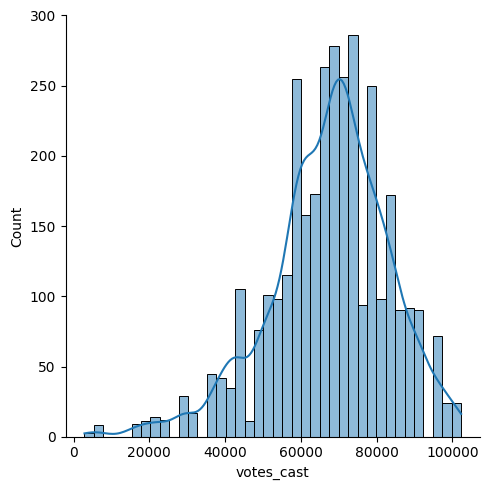

In [64]:
sns.displot(kind='hist', data=df, x='votes_cast', kde=True)

- *Most constituencies recorded total voter participation between **50,000 and 90,000**, indicating that this is the most common voter participation range in the dataset.*

In [65]:
df['votes_cast'].skew()

np.float64(-0.6198506049024454)

- *The data shows a slight **left skew (-ve)**, but the overall distribution is relatively close to normal.*

<Axes: ylabel='votes_cast'>

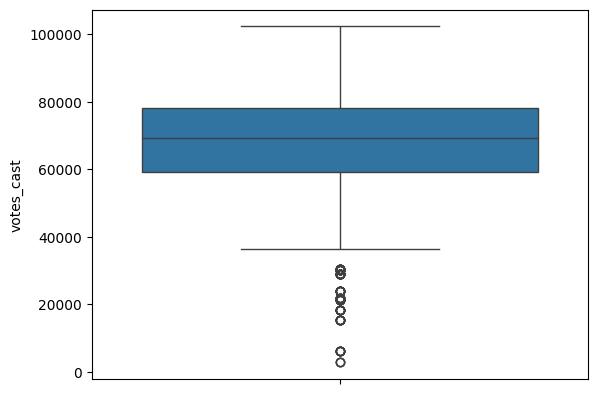

In [66]:
sns.boxplot(df['votes_cast'])

- *Although participation values below **40,000** appear as outliers, they may still be valid because election participation can vary significantly across different regions and constituencies.*

In [67]:
df[df['votes_cast'] < 40000]

,candidate_id,candidate,age,party,party_id,votes,gender,is_winner,father,qualification,...,spouse,experience,province,district,constituency,votes_cast,total_voters,education_category,latitude,longitude
161,340612,Santosha Subva,48,Nepali Congress,2583.0,11561,M,True,सुरेश कुमार निङलेकु,एल.एल.बि,...,नैना कुमारी स‌ंग्रौला सुब्बा),NaN,Koshi,Tehrathum,Tehrathum-1,36795,73093,Bachelor's Degree,27.1333,87.5333
162,340855,Bhanu Bhakta Dhakal,64,Nepal Communist Party (Ekikrit Marxbadi Leninb...,2598.0,10682,M,False,कुल प्रसाद ढकाल,बि.एड. एम.ए समाज शास्त्र,...,इन्दिरा फुयौल ढकाल,NaN,Koshi,Tehrathum,Tehrathum-1,36795,73093,Master's Degree,27.1333,87.5333
163,342758,Surendra Karki,28,Rastriya Swatantra Party,2528.0,7737,M,False,विरेन्द्र कार्की,NaN,...,NaN,NaN,Koshi,Tehrathum,Tehrathum-1,36795,73093,NaN,27.1333,87.5333
164,339986,Suvindra Kumara Limvu,46,Shram Sanskriti Party,2501.0,5200,M,False,हस्त बहादुर लिम्वु,स्नातक तह,...,लक्ष्मी लिम्वु,NaN,Koshi,Tehrathum,Tehrathum-1,36795,73093,Bachelor's Degree,27.1333,87.5333
165,341720,Ranadhvaja Limvu,67,Nepali Communist Party,2557.0,919,M,False,राज बहादुर लिम्वु,NaN,...,NaN,NaN,Koshi,Tehrathum,Tehrathum-1,36795,73093,NaN,27.1333,87.5333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3153,341837,Shera Bahadura Vi K,42,Nepal Communist Party (Maoist),2526.0,558,M,False,नैने कामी,Bachelor pass,...,दुरा कुमारी कामी,NaN,Sudurpashchim,Achham,Achham-2,30569,82787,Bachelor's Degree,29.0667,81.2000
3154,340744,Min Bahadur Shahi,52,Rastriya Prajatantra Party,2604.0,167,M,False,Jora Singh Shahi,12 pass,...,Devki Shahi,NaN,Sudurpashchim,Achham,Achham-2,30569,82787,Higher Secondary / Intermediate (10+2 / PCL),29.0667,81.2000
3155,341537,Pushpa Raj Neupane,43,Pragatishil Loktantrik Party,2516.0,113,M,False,Jakti Ram Upadhyaya,Bacherlor,...,Durga Paudyal,worked in radio Nepal,Sudurpashchim,Achham,Achham-2,30569,82787,Bachelor's Degree,29.0667,81.2000
3156,339960,Jhankar Bahadur Shahi,44,Nepal Majdur Kisan Party,2578.0,60,M,False,Tek Bahadur Shahi,12 pass,...,Suntali Shahi,NaN,Sudurpashchim,Achham,Achham-2,30569,82787,Higher Secondary / Intermediate (10+2 / PCL),29.0667,81.2000


- ***Tehrathum-1**, **Achham-2**, **Manang-1**, **and similar constituencies** recorded relatively lower voter participation, which may be associated with differences in population size, geographic accessibility, and regional conditions.*

In [68]:
df['votes_cast'].isna().sum()

np.int64(0)

### `total_voters` → (num)

In [69]:
df['total_voters'].describe()

count      3406.000000
mean     117135.224897
std       26983.488274
min        7000.000000
25%      105909.000000
50%      117917.000000
75%      134426.000000
max      187939.000000
Name: total_voters, dtype: float64

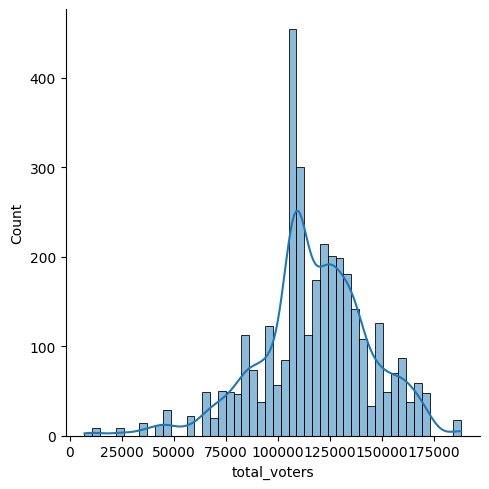

In [70]:
sns.displot(kind='hist', data=df, x='total_voters', kde=True)

- *Total voters represent the eligible voters registered in the constituency. Among them, some participated in the election, while others did not, meaning this value indicates the potential voter base rather than actual voter turnout.*

- *The distribution shows that the **90,000–150,000** interval occurs most frequently, indicating that this is the most common range of registered voters across constituencies.*

In [71]:
df['total_voters'].skew()

np.float64(-0.46907549153236916)

- *The distribution shows a mild **left skew**, indicating that lower values are less frequent but contribute to the slight imbalance in the distribution.*

<Axes: ylabel='total_voters'>

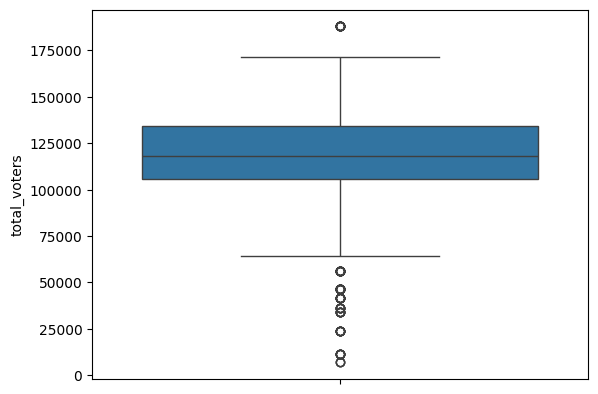

In [72]:
sns.boxplot(df['total_voters'])

- *The analysis identifies values above **175,000** and below **60,000** as potential outliers. However, these cases may be valid because election-related data naturally varies across different constituencies.*

In [73]:
df[~df['total_voters'].between(60000, 175000)].sort_values(by='total_voters', ascending=False)

,candidate_id,candidate,age,party,party_id,votes,gender,is_winner,father,qualification,...,spouse,experience,province,district,constituency,votes_cast,total_voters,education_category,latitude,longitude
768,340091,Krishna Hari Budhathoki,44,Rastriya Swatantra Party,2528.0,24808,M,True,गणेश बहादुर बुढाथोकी,Ph.D,...,सुजा बुढाथोकी,वैकिङ्ग वित्तिय क्षेत्र सामाजिक मानवीय भूमिका ...,Bagmati,Ramechhap,Ramechhap-1,81994,187939,Doctorate / PhD,27.3333,86.0833
769,340239,Madhav Prasad Dhungel,48,Nepal Communist Party (Ekikrit Marxbadi Leninb...,2598.0,17609,M,False,Bodh Raj Dhungel,स्नाकोत्तर,...,Sarita Dhungel,NaN,Bagmati,Ramechhap,Ramechhap-1,81994,187939,Master's Degree,27.3333,86.0833
770,341939,Ram Chandra Khadka,65,Nepali Congress,2583.0,16307,M,False,Bhakta Bahadur Khadka,स्नातक,...,Urmila Khadka,शिक्षण सामाजिक राजिनितिक,Bagmati,Ramechhap,Ramechhap-1,81994,187939,Bachelor's Degree,27.3333,86.0833
771,339706,Shyam Kumar Shrestha,54,Nepali Communist Party,2557.0,13354,M,False,Tirtha Das Shrestha,M.A.,...,Tika Maya Shrestha,2048 सालदेखी राजनितिक सामाजिक क्षेत्रमा निरन्त...,Bagmati,Ramechhap,Ramechhap-1,81994,187939,Master's Degree,27.3333,86.0833
772,341242,Dip Bahadur Yonjan,42,Ujyalo Nepal Party,2566.0,7201,M,False,Singh Bahadur Tamang,+2,...,NaN,समाजसेवी सामाजिक अभियान्ता,Bagmati,Ramechhap,Ramechhap-1,81994,187939,Higher Secondary / Intermediate (10+2 / PCL),27.3333,86.0833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,339737,Indra Dhara Dadu Bista,56,Nepal Communist Party (Ekikrit Marxbadi Leninb...,2598.0,1806,M,False,Tenpa Bista,१० पास,...,Chhimi Bishta,NaN,Gandaki,Mustang,Mustang-1,6281,11325,Secondary Education (Grade 9-10 / SLC / SEE),28.9833,83.8500
2770,340370,Kamala Lalchan,60,Rastriya Prajatantra Party,2604.0,161,F,False,Buddhi Bahadur Lalchan,वि.एड,...,Shrikant Adhikari,शिक्षक,Gandaki,Mustang,Mustang-1,6281,11325,Bachelor's Degree,28.9833,83.8500
2278,339862,Tek Bahadur Gurung,71,Nepali Congress,2583.0,2415,M,True,Kaji Gurung,slc,...,Sunad Gurung Ghaleseni,समाजसेवी तथा जनप्रतिनिधि भइसकेको,Gandaki,Manang,Manang-1,2878,7000,Secondary Education (Grade 9-10 / SLC / SEE),28.5500,84.2333
2279,340431,Yashoda Gurung (Subedi),57,Nepali Communist Party,2557.0,454,F,False,Romharsh Subedi,प्रविणता प्रमाण पत्र तह,...,Dev Prasad Gurung,क)अध्यापन 5 वर्ष\nख) राजनितिक ४४ वर्ष\nग) संवि...,Gandaki,Manang,Manang-1,2878,7000,Higher Secondary / Intermediate (10+2 / PCL),28.5500,84.2333


- ***Ramechhap-1** recorded the highest number of registered voters (**187,939**), whereas **Manang-1** had the lowest (**7,000**). This variation is likely influenced by differences in population distribution, settlement patterns, and regional characteristics.*

### `party` → (cat)

In [74]:
df['party'].value_counts()

party
Swatantra                                                1143
Nepali Congress                                           165
Nepal Communist Party (Ekikrit Marxbadi Leninbadi)        164
Nepali Communist Party                                    164
Rastriya Swatantra Party                                  164
                                                         ... 
Rastriya Janata Party Nepal                                 1
Rastriya Nagarik Party                                      1
Nepal Communist Party (Marxbadi) (Ekal Chunab Chinha)       1
Nepal Matribhumi Party                                      1
Gandhiwadi Party Nepal                                      1
Name: count, Length: 66, dtype: int64

<Axes: xlabel='party'>

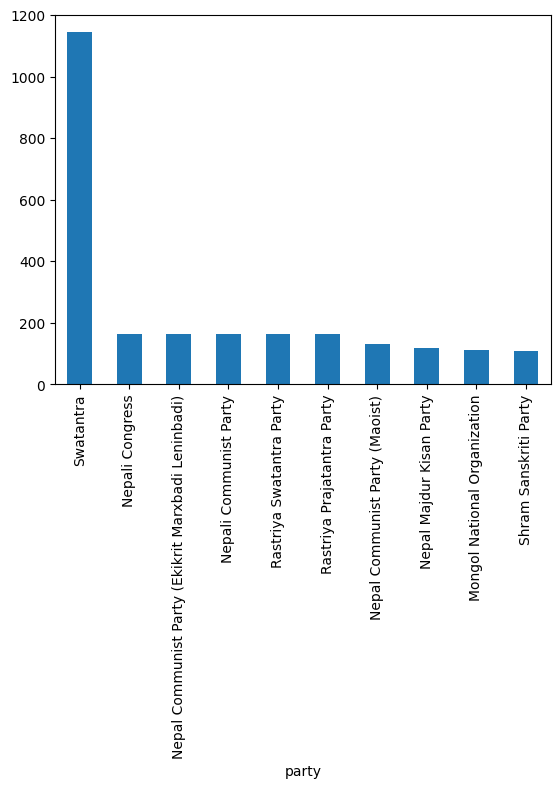

In [75]:
# Plot a graph of top 10 parties
df['party'].value_counts().head(10).plot(kind='bar')

- ***Swatantra** appears most frequently in the dataset, suggesting that the party field contains the highest number of candidates from this party.*

<Axes: ylabel='count'>

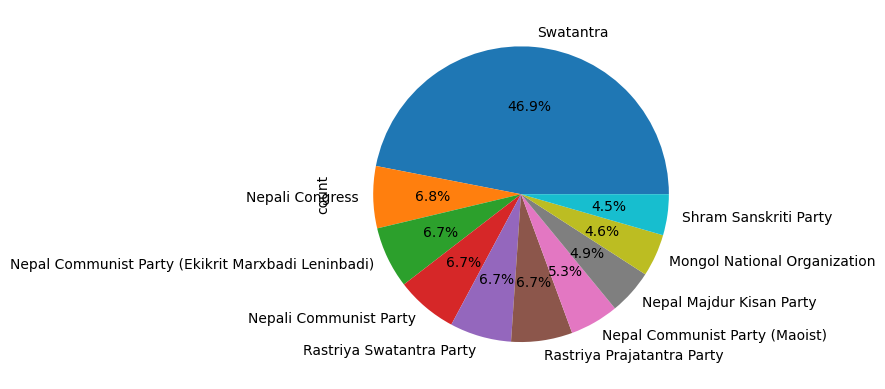

In [76]:
df['party'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')

In [77]:
df['party'].isna().sum()

np.int64(0)

### `gender` → (cat)

In [78]:
df['gender'].value_counts()

gender
M    3018
F     388
Name: count, dtype: int64

<Axes: xlabel='gender'>

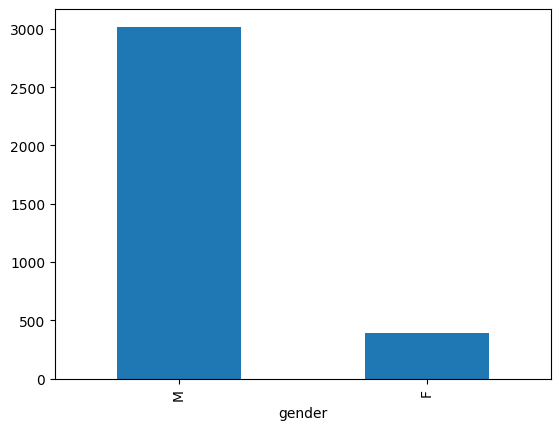

In [79]:
df['gender'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

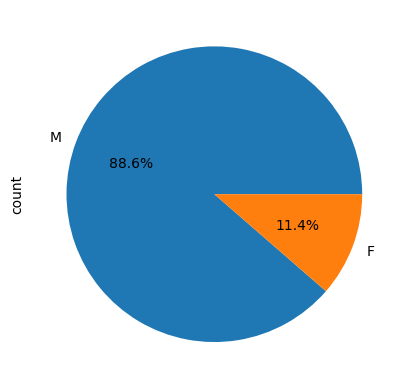

In [80]:
df['gender'].value_counts().plot(kind='pie', autopct='%0.1f%%')

- *The dataset is dominated by **male candidates**, who comprise **88.6%** of the total, whereas **female candidates** account for just **11.4%**.*

In [81]:
df['gender'].isna().sum()

np.int64(0)

### `education_category` → (cat)

In [82]:
df['education_category'].value_counts()

education_category
Secondary Education (Grade 9-10 / SLC / SEE)    739
Higher Secondary / Intermediate (10+2 / PCL)    626
Bachelor's Degree                               564
Master's Degree                                 343
Literate / Non-Formal                           263
Basic Education (Up to Grade 8)                  99
Doctorate / PhD                                  59
Diploma / Certificate Level                      26
Illiterate                                       13
Unspecified / Others                              9
M.Phil                                            8
Name: count, dtype: int64

<Axes: xlabel='education_category'>

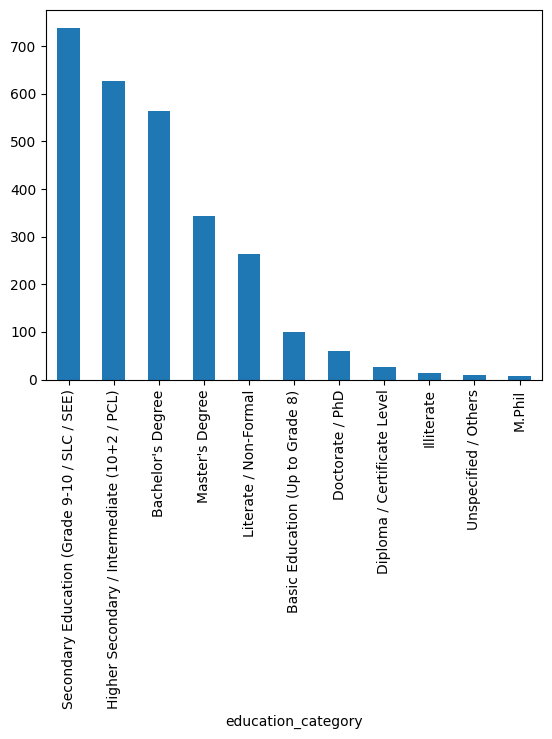

In [83]:
df['education_category'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

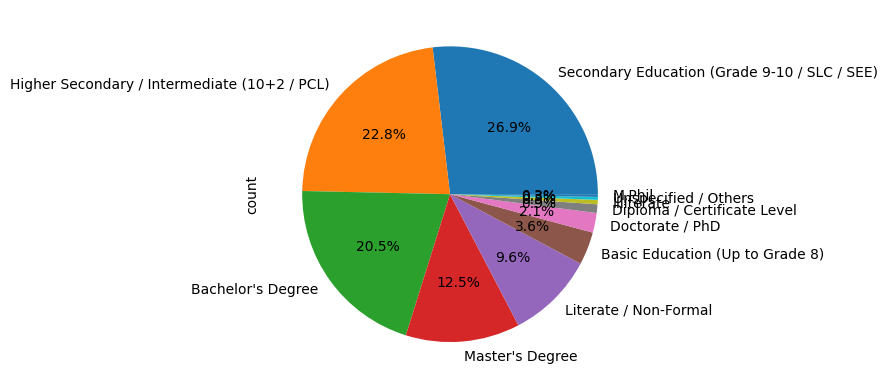

In [84]:
df['education_category'].value_counts().plot(kind='pie', autopct='%0.1f%%')

- *Most candidates have **Secondary Education** (**26.9%**), followed by **Higher Secondary** (**22.8%**) and a **Bachelor's Degree** (**20.5%**).*

In [85]:
df['education_category'].isna().sum()

np.int64(657)

In [86]:
round(number=(657/3406) * 100, ndigits=2)

19.29

- *Approximately **19.3%** of the values in this column are missing, meaning that roughly **1 out of every 5 rows** contains a missing value.*

- *`1 out of every 5 rows` because: **19.3% ≈ 1 in 5 (20%)***


### `constituency` → (cat)

In [87]:
df['constituency'].value_counts()

constituency
Dhanusha-3     45
Dhanusha-1     42
Mahottari-3    41
Siraha-3       41
Rautahat-3     40
               ..
Mustang-1       8
Humla-1         7
Mugu-1          7
Bajhang-1       7
Manang-1        3
Name: count, Length: 165, dtype: int64

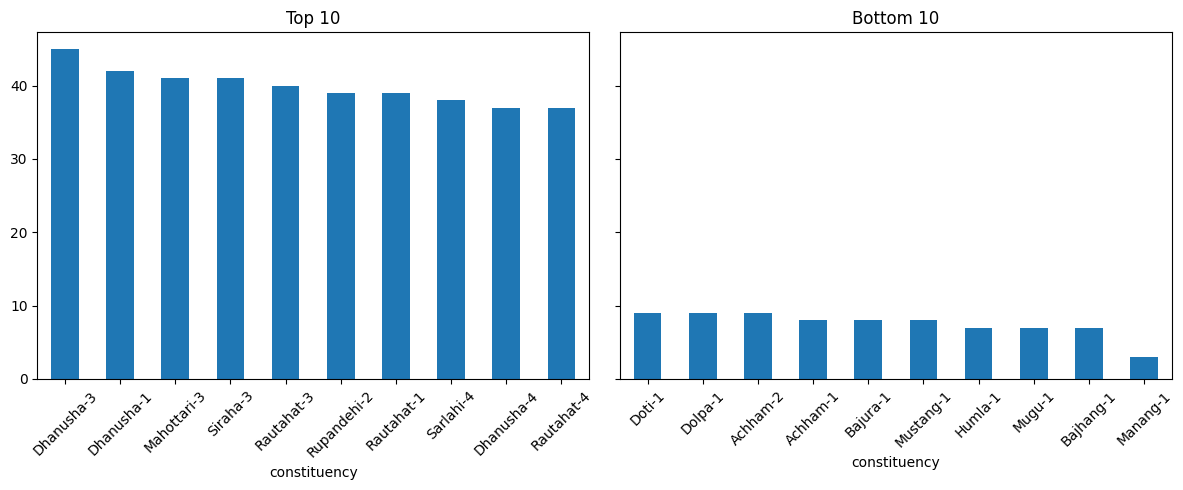

In [88]:
# Plot a graph of top 10 and bottom 10 constituencies
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2, sharey=True, figsize=(12,5))


# Subplot 1: Top 10 constituencies
df['constituency'].value_counts().head(10).plot(kind='bar', ax=ax1, title="Top 10", rot=45)

# Subplot 2: Bottom 10 constituencies
df['constituency'].value_counts().tail(10).plot(kind='bar', ax=ax2, title="Bottom 10", rot=45)

plt.tight_layout()  # Automatically adjusts spacing btn two graphs
plt.show()

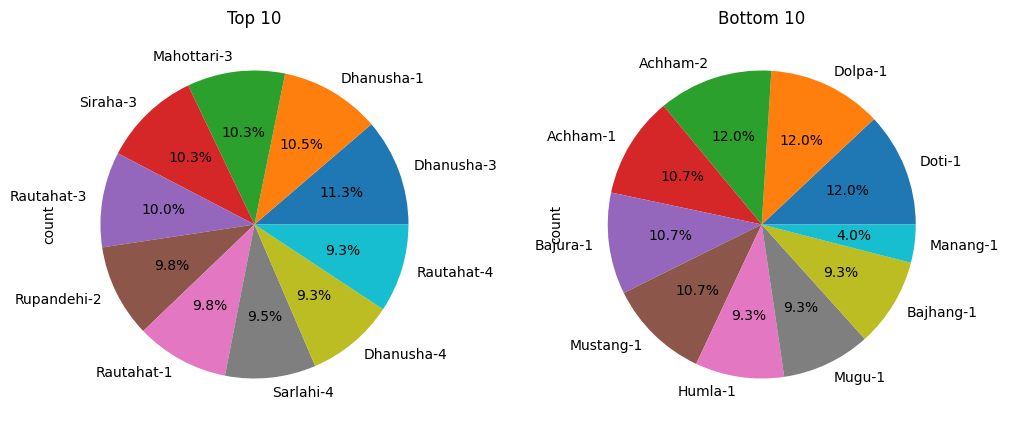

In [89]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

df['constituency'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%', ax=ax1, title="Top 10")
df['constituency'].value_counts().tail(10).plot(kind='pie', autopct='%0.1f%%', ax=ax2, title="Bottom 10")

plt.show()

In [90]:
df['constituency'].isna().sum()

np.int64(0)

### `province` → (cat)

In [91]:
df['province'].value_counts()

province
Madhesh          1027
Bagmati           731
Lumbini           582
Koshi             495
Gandaki           234
Sudurpashchim     206
Karnali           131
Name: count, dtype: int64

<Axes: xlabel='province'>

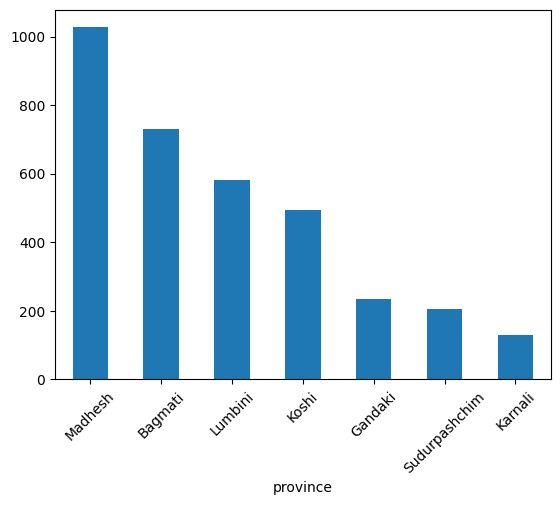

In [92]:
df['province'].value_counts().plot(kind='bar', rot=45)

<Axes: ylabel='count'>

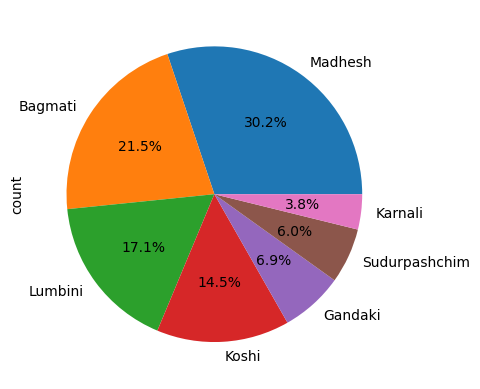

In [93]:
df['province'].value_counts().plot(kind='pie', autopct='%0.1f%%')

- ***Madhesh Province** is the most frequently represented province, accounting for **30.2%** of the dataset, followed by **Bagmati Province** (**21.5%**) and **Lumbini Province** (**17.1%**).*

In [94]:
df['province'].isna().sum()

np.int64(0)

### `district` → (cat)

In [95]:
df['district'].value_counts()

district
Kathmandu    250
Dhanusha     158
Rupandehi    155
Rautahat     142
Mahottari    139
            ... 
Mustang        8
Humla          7
Mugu           7
Bajhang        7
Manang         3
Name: count, Length: 77, dtype: int64

<Axes: xlabel='district'>

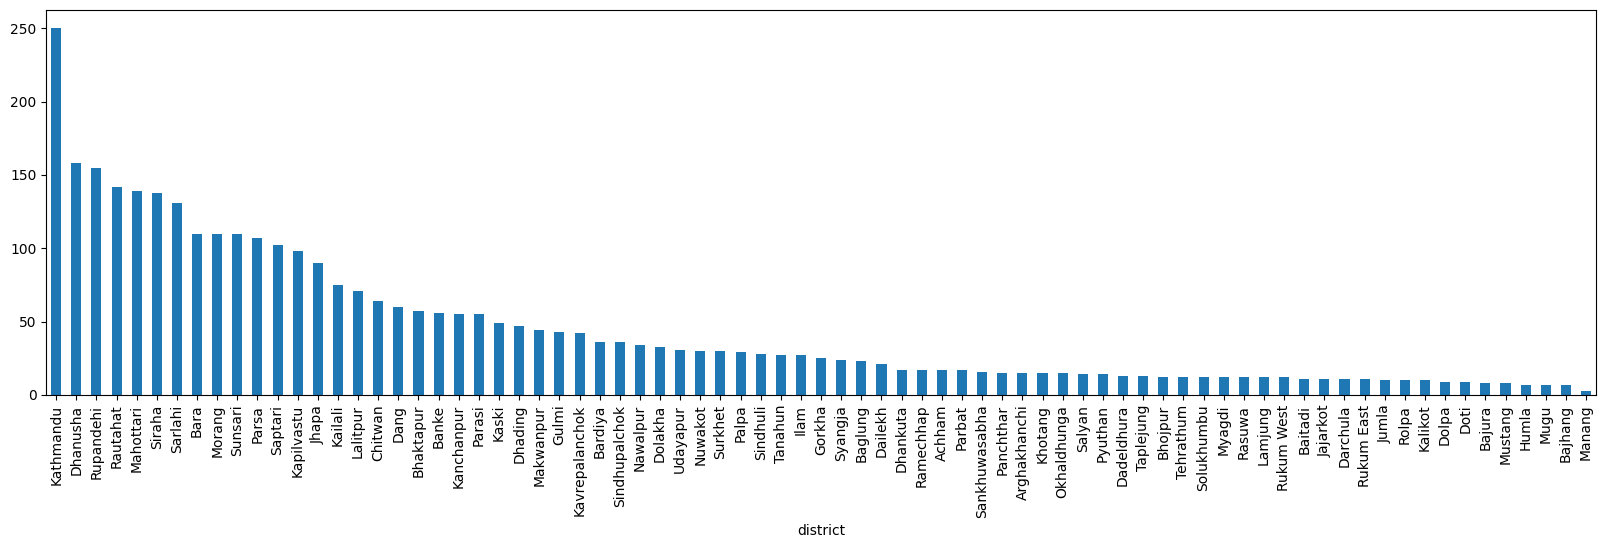

In [96]:
df['district'].value_counts().plot(kind='bar', figsize=(20, 5))

<Axes: ylabel='count'>

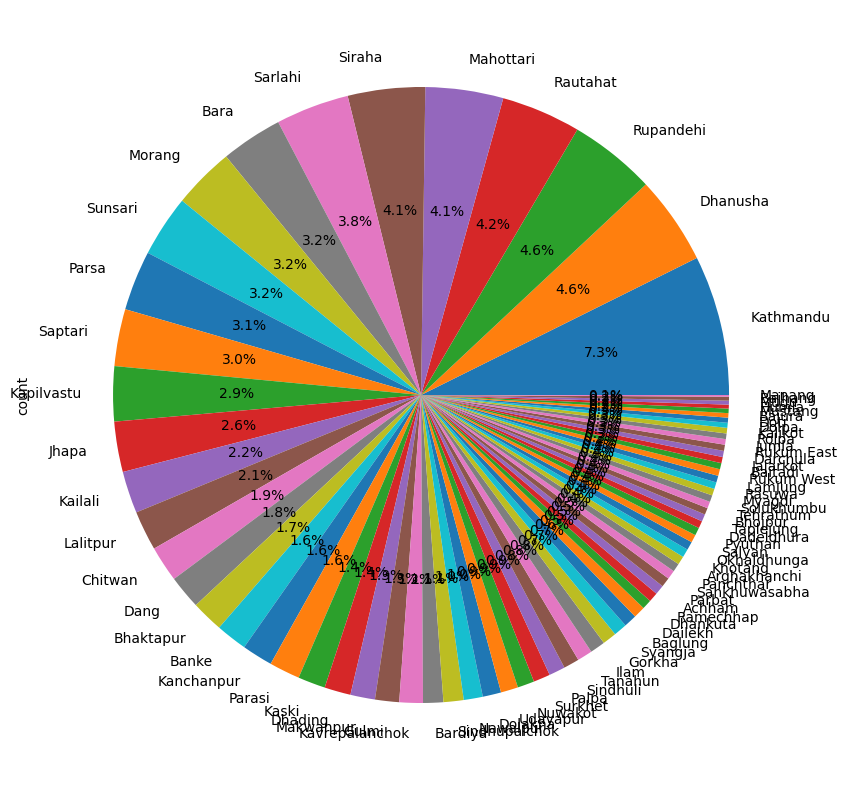

In [97]:
df['district'].value_counts().plot(kind='pie', autopct='%0.1f%%', figsize=(10,10))

In [98]:
df['district'].isna().sum()

np.int64(0)

### `address` → (cat)

In [99]:
df['address'].value_counts()

address
Kathmandu                                                                 121
Rupandehi                                                                  83
Mahottari                                                                  77
Siraha                                                                     76
Sarlahi                                                                    71
                                                                         ... 
Nawalparasi (Bardghat Susta West) Ramgram Municipality Piprahiya            1
Nawalparasi (Bardghat Susta West) Sunwal Municipality Sundarvasti           1
Navalparasi (Bardghat Susta West) Palhinandan Rural Municipality Palhi      1
Nawalparasi (Bardghat Susta West) Sunwal Municipality Mangalnagar           1
Jhapa Mechinagar Municipality Ward Khal                                     1
Name: count, Length: 1426, dtype: int64

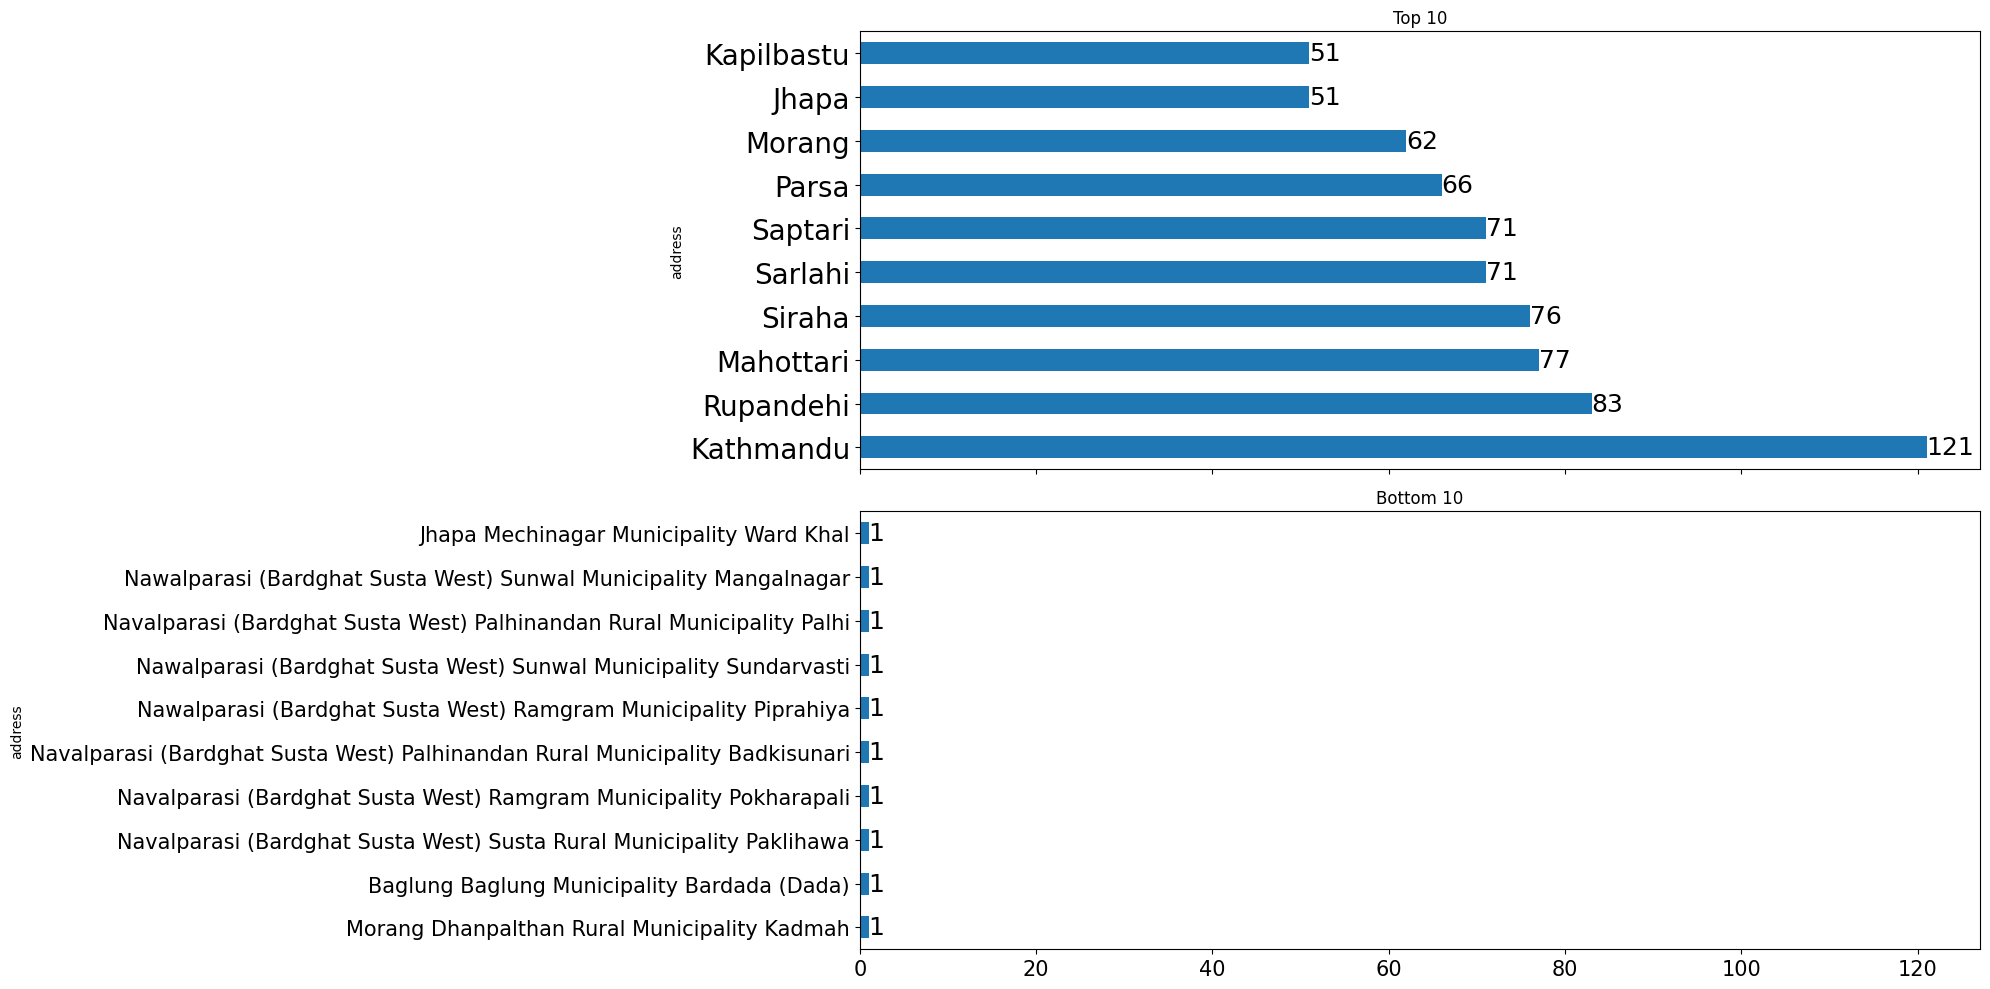

In [100]:
# Plot a graph of top 10 and bottom 10 candidates' address
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(20,10))

df['address'].value_counts().head(10).plot(kind='barh', ax=ax1, title="Top 10", fontsize=20)
ax1.bar_label(ax1.containers[0], fontsize=18) # add bar label

df['address'].value_counts().tail(10).plot(kind='barh', ax=ax2, title="Bottom 10", fontsize=15)
ax2.bar_label(ax2.containers[0], fontsize=18)

plt.tight_layout()
plt.show()

In [101]:
ax1.containers[0]

<BarContainer object of 10 artists>

In [102]:
type(ax1.containers[0])

matplotlib.container.BarContainer

<Axes: ylabel='count'>

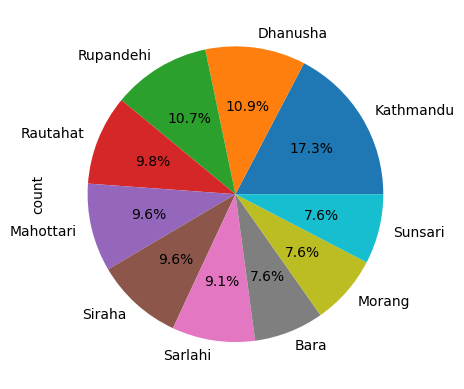

In [103]:
df['district'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')

- *Most candidates' **living addresses** are in **Kathmandu** (**17.3%**), followed by **Dhanusha** (**10.9%**) and **Rupandehi** (**10.7%**).*

In [104]:
df['address'].isna().sum()

np.int64(0)

### `is_winner` → (cat)

In [105]:
df[df['is_winner'] == True]['party'].value_counts()

party
Rastriya Swatantra Party                              125
Nepali Congress                                        18
Nepal Communist Party (Ekikrit Marxbadi Leninbadi)      9
Nepali Communist Party                                  8
Shram Sanskriti Party                                   3
Rastriya Prajatantra Party                              1
Name: count, dtype: int64

<Axes: ylabel='count'>

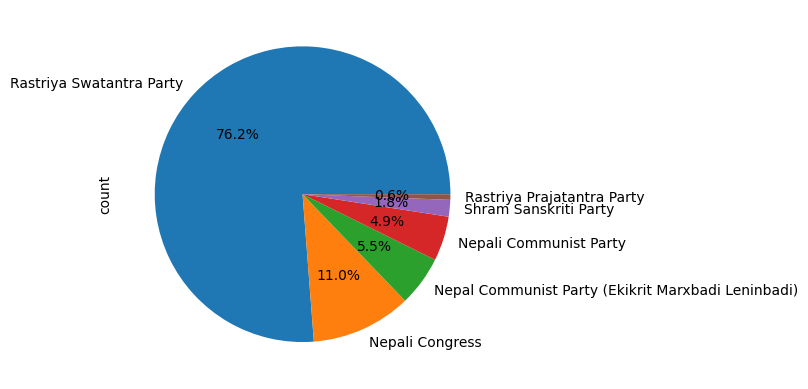

In [106]:
df[df['is_winner'] == True]['party'].value_counts().plot(kind='pie', autopct='%0.1f%%')

- *The **Rastriya Swatantra Party** achieved the highest representation in direct seats, winning **125 seats** and maintaining a **76.2% success rate**.*

In [107]:
df['is_winner'].isna().sum()

np.int64(0)

## 3. **Bivariate = two variables**

* **Numerical–Numerical:** scatter plot, correlation
* **Numerical–Categorical:** box plot, bar plot
* **Categorical–Categorical:** crosstab, heatmap

> ***Note:** In this analysis, **votes are considered the target variable** and are compared with other features to understand how different factors are related to vote outcomes.*

### `votes` ↔ `age` (num-num)

<Axes: xlabel='age', ylabel='votes'>

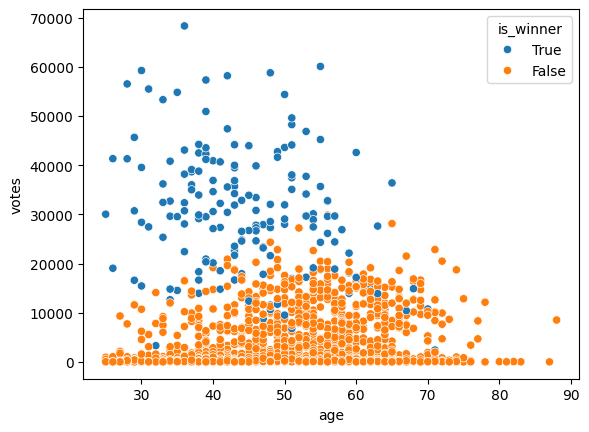

In [108]:
sns.scatterplot(data=df, x='age', y='votes', hue='is_winner', hue_order=[True,False])

- *The analysis indicates a negative relationship between candidate **age** and **votes**, where older candidates generally tend to receive fewer votes compared to younger candidates.*

### `votes` ↔ `votes_cast` (num-num)

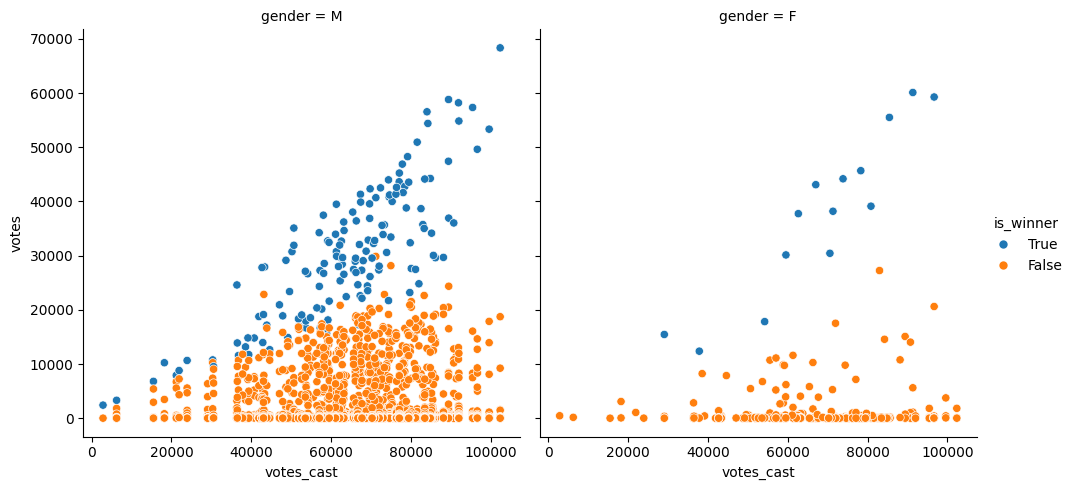

In [109]:
sns.relplot(kind='scatter', data=df, x='votes_cast', y='votes', hue='is_winner', hue_order=[True,False], col='gender')

- ***Pattern 1:** A positive relationship is observed between **votes** and **votes_cast**, indicating that constituencies with a higher number of votes cast generally tend to produce candidates with higher vote counts.*

- ***Pattern 2:** Most candidates who **did not win the election** received **fewer than 20,000 votes** and are concentrated in constituencies where **35,000–90,000 votes were cast**. This suggests that moderate-turnout constituencies contain the largest share of unsuccessful candidates.*

### `votes` ↔ `total_voters` (num-num)

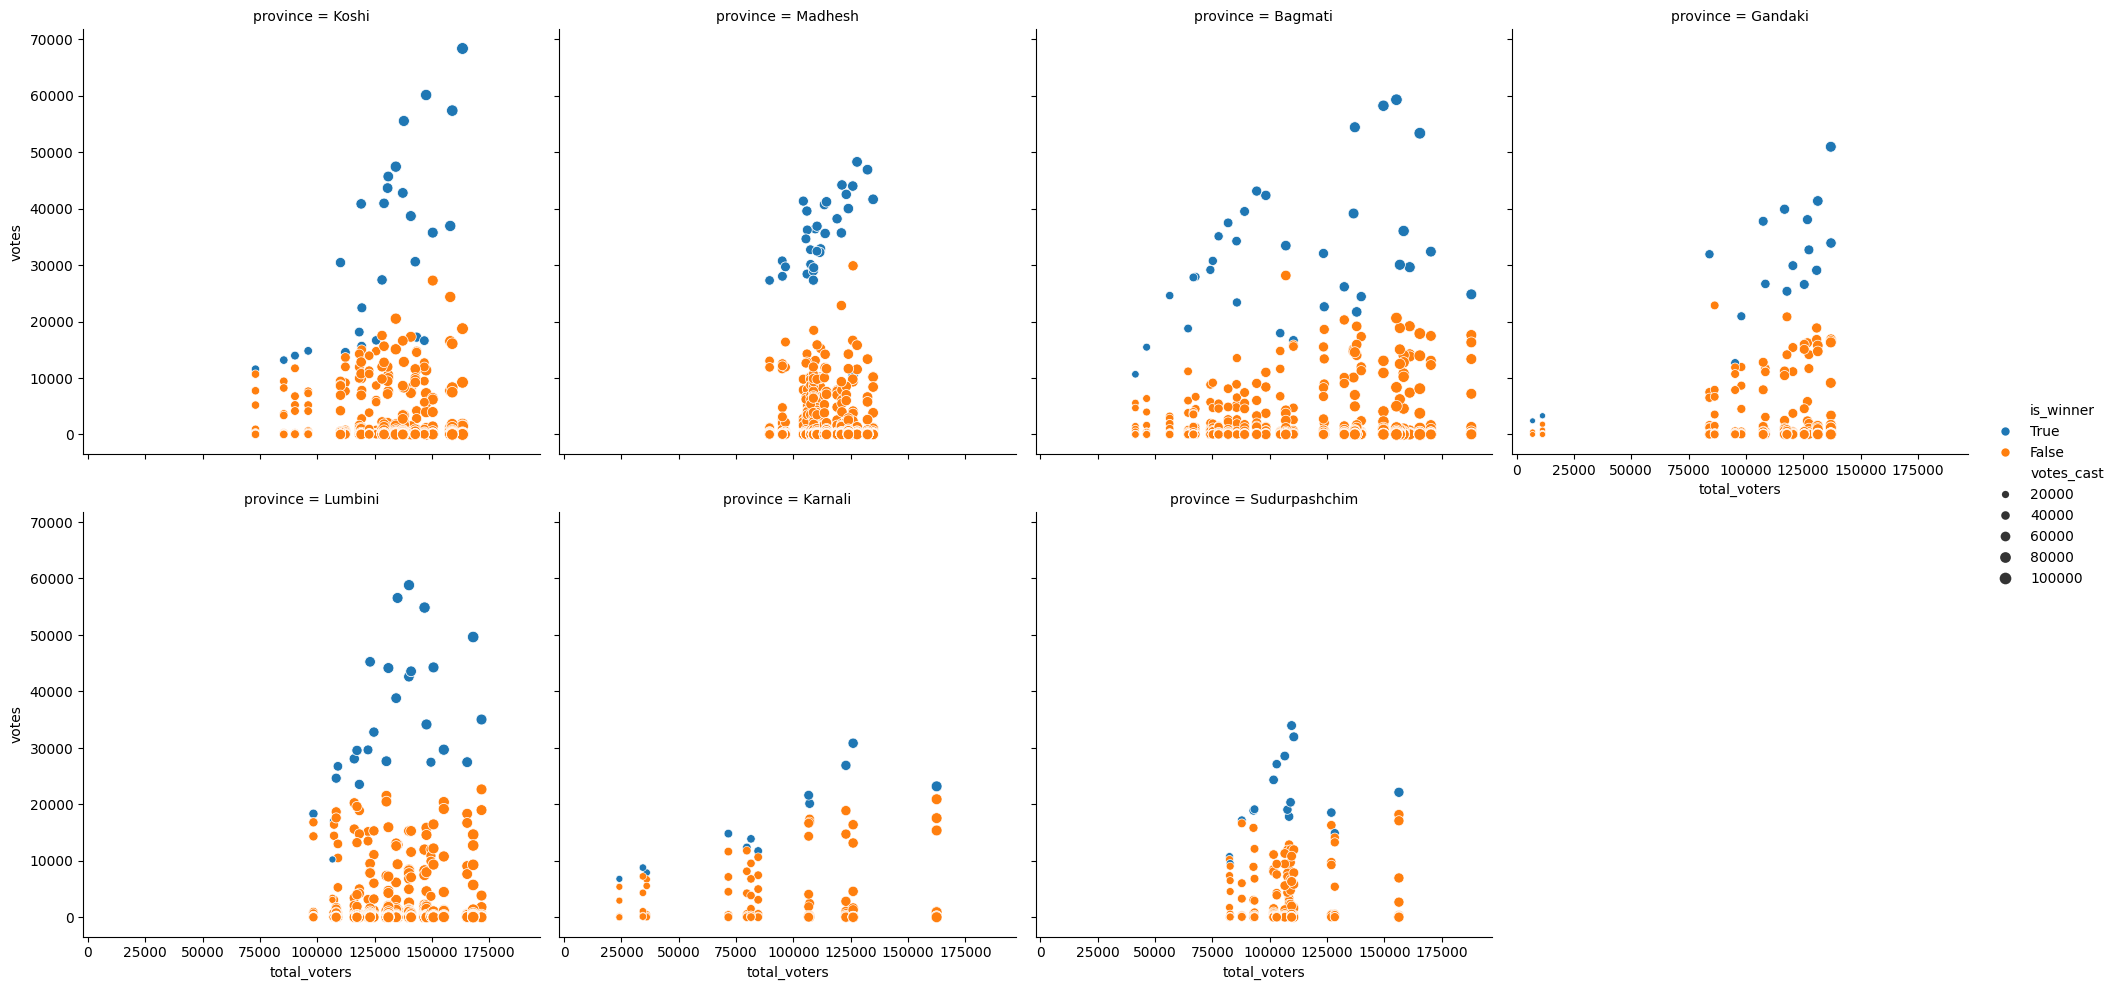

In [110]:
sns.relplot(kind='scatter', data=df, x='total_voters', y='votes', hue='is_winner', hue_order=[True,False], size='votes_cast', col='province', col_wrap=4)

- *A general positive pattern is observed: as the number of **registered voters** increases, the **number of votes received** also tends to increase.*

### `votes` ↔ `party` (num-cat)

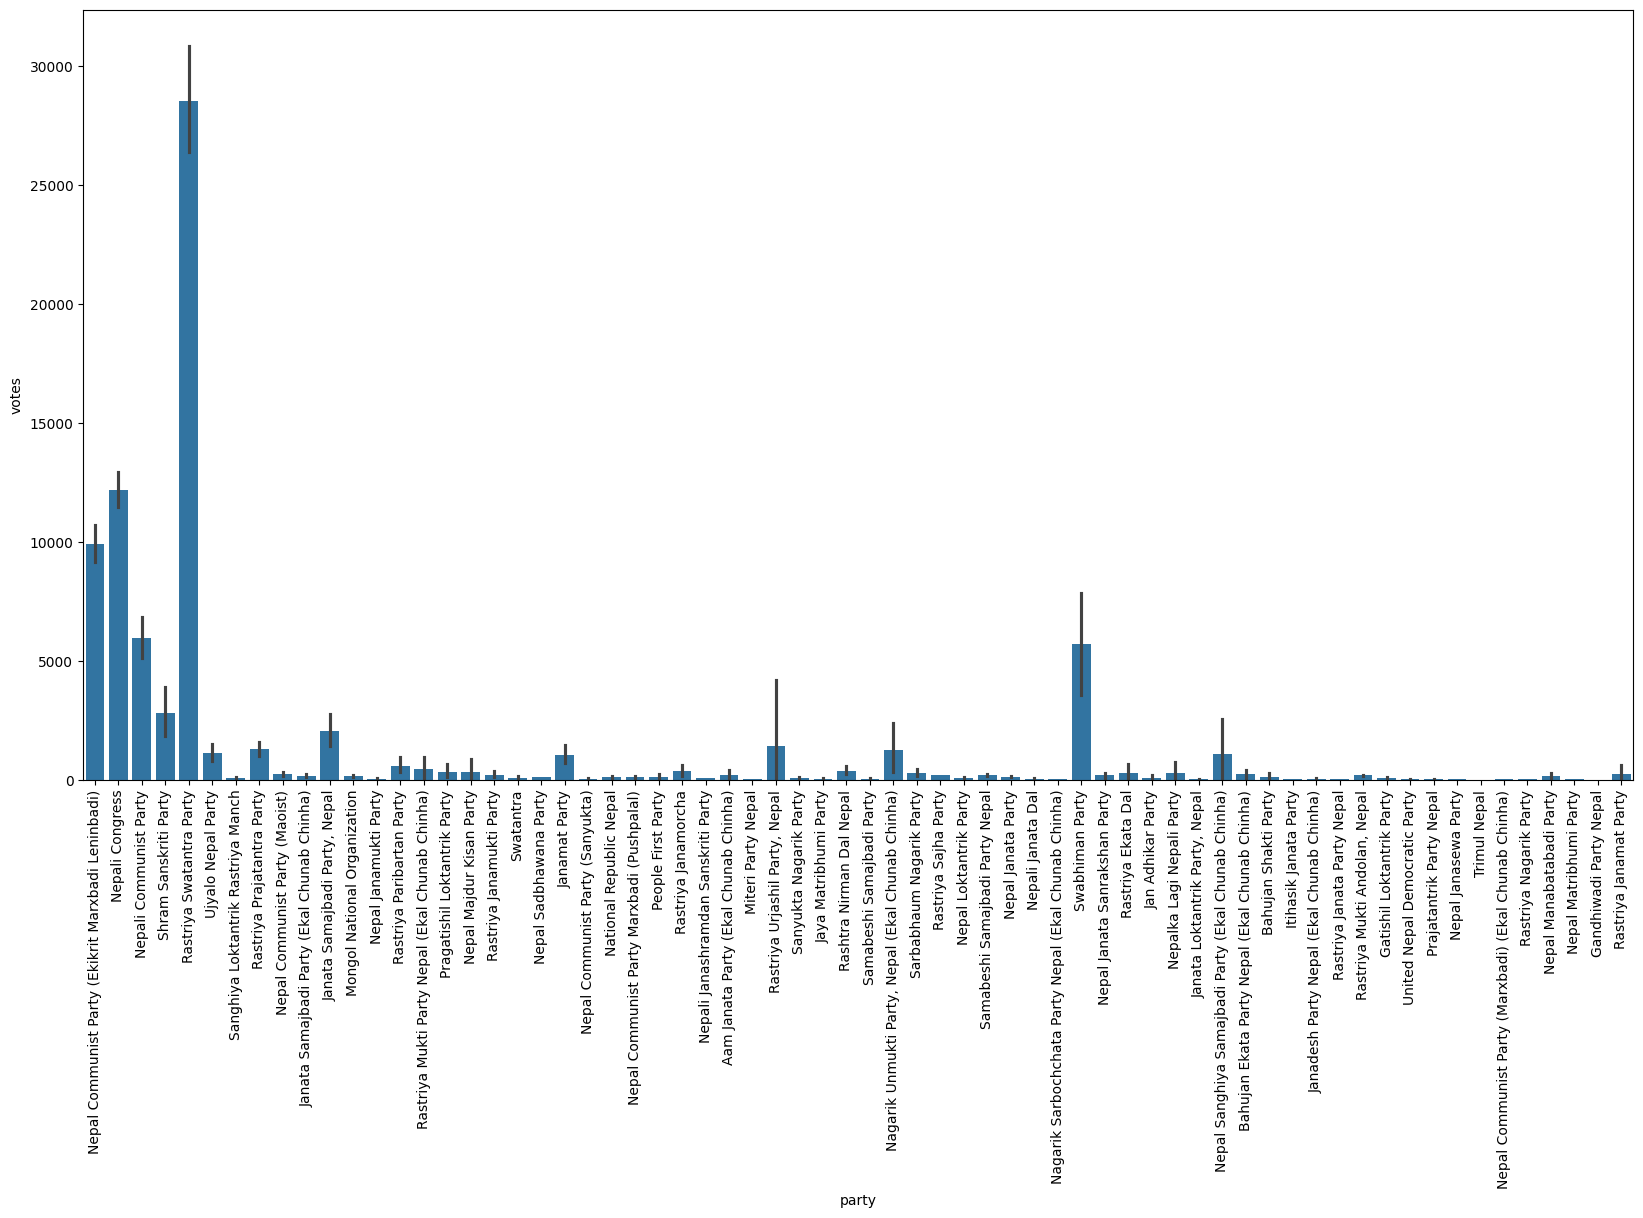

In [111]:
plt.figure(figsize=(20,10))

sns.barplot(data=df, x='party', y='votes')

plt.xticks(rotation='vertical')

plt.show()

> ***Note:** To improve the clarity of the analysis, only parties receiving **1,000 or more votes on Average** are considered. Excluding parties with very low vote counts helps reduce noise and allows the analysis to focus on parties with substantial electoral representation.*

In [112]:
temp_seri = df.pivot_table(values='votes', index='party', aggfunc='mean')['votes']

In [113]:
temp_seri = temp_seri[temp_seri >= 1000]
temp_seri

party
Janamat Party                                           1045.311475
Janata Samajbadi Party, Nepal                           2056.414894
Nagarik Unmukti Party, Nepal (Ekal Chunab Chinha)       1239.500000
Nepal Communist Party (Ekikrit Marxbadi Leninbadi)      9897.310976
Nepal Sanghiya Samajbadi Party (Ekal Chunab Chinha)     1069.250000
Nepali Communist Party                                  5951.317073
Nepali Congress                                        12173.569697
Rastriya Prajatantra Party                              1271.595092
Rastriya Swatantra Party                               28540.000000
Rastriya Urjashil Party, Nepal                          1434.666667
Shram Sanskriti Party                                   2788.091743
Swabhiman Party                                         5702.000000
Ujyalo Nepal Party                                      1104.523810
Name: votes, dtype: float64

<Axes: ylabel='party'>

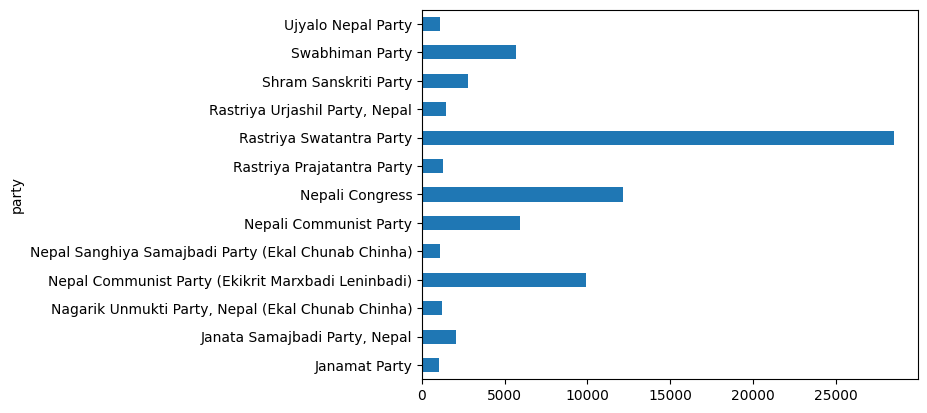

In [114]:
temp_seri.plot(kind='barh')

- *The **Rastriya Swatantra Party** leads by a substantial margin with an average of **28,540 votes** per candidate. It is followed by the **Nepali Congress** (**12,174**), the **Nepal Communist Party (Ekikrit Marxbadi Leninbadi)** (**9,897**), **Nepali Communist Party** (**5,951**), and the **Swabhiman Party** (**5,702**).*

### `votes` ↔ `gender` (num-cat)

<Axes: xlabel='gender', ylabel='votes'>

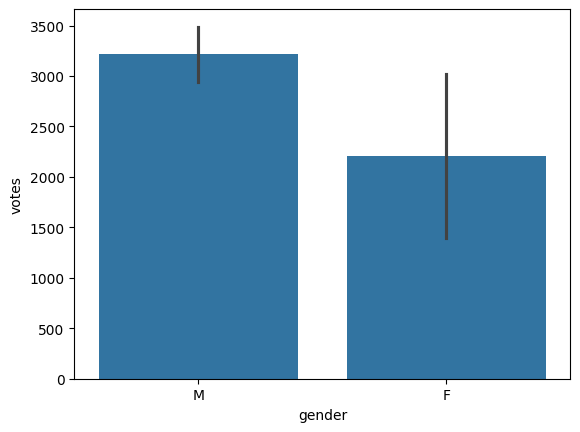

In [115]:
sns.barplot(data=df, x='gender', y='votes')

<Axes: xlabel='gender', ylabel='votes'>

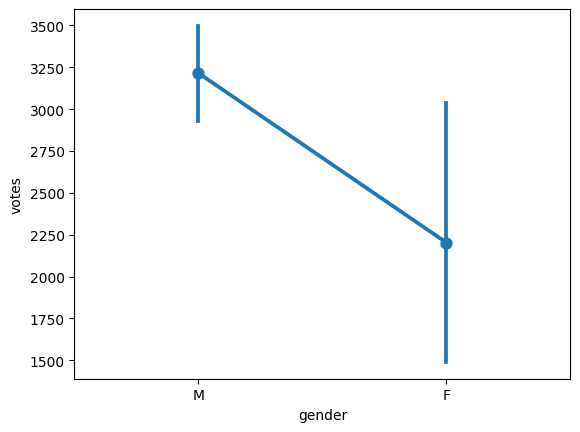

In [116]:
sns.pointplot(data=df, x='gender', y='votes')

- *On average, **male candidates** received around **3,250 votes**, compared to approximately **2,250 votes** for **female candidates**.*

### `votes` ↔ `education_category` (num-cat)

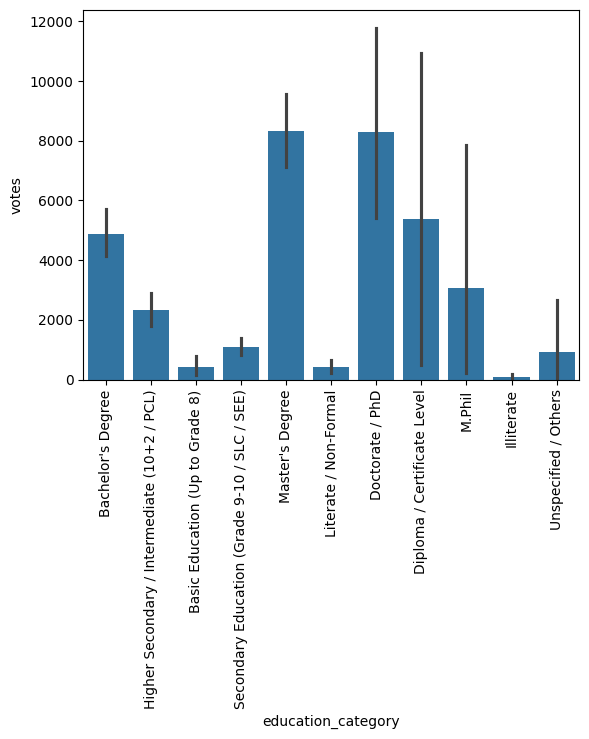

In [117]:
sns.barplot(data=df, x='education_category', y='votes')
plt.xticks(rotation=90)

plt.show()

- *Candidates with **Master's and PhD qualifications** received an average of approximately **8,300 votes**, whereas **illiterate candidates** received fewer than **500 votes on average**.*

### `votes` ↔ `constituency` (num-cat)

In [118]:
df['constituency'].value_counts()

constituency
Dhanusha-3     45
Dhanusha-1     42
Mahottari-3    41
Siraha-3       41
Rautahat-3     40
               ..
Mustang-1       8
Humla-1         7
Mugu-1          7
Bajhang-1       7
Manang-1        3
Name: count, Length: 165, dtype: int64

> ***Note:** To make the analysis more meaningful, only constituencies with an **average of at least 5,000 votes** are included. This helps reduce the impact of low-vote constituencies and highlights patterns among constituencies with stronger electoral participation.*

In [119]:
temp_seri = df.pivot_table(values='votes', index='constituency', aggfunc='mean')['votes']

In [120]:
temp_seri = temp_seri[temp_seri >= 5000]
temp_seri

constituency
Arghakhanchi-1    5553.733333
Baitadi-1         6157.272727
Bajhang-1         7833.285714
Bajura-1          5487.000000
Banke-1           5064.785714
Bardiya-2         5875.333333
Chitwan-1         5105.500000
Dang-1            5456.357143
Doti-1            5463.111111
Gorkha-1          5115.833333
Jajarkot-1        5242.545455
Jhapa-1           5219.400000
Jhapa-2           5073.500000
Kailali-3         5131.181818
Lamjung-1         6084.166667
Morang-6          5026.764706
Nawalpur-1        5097.375000
Nuwakot-2         5590.833333
Pyuthan-1         5796.142857
Rolpa-1           6563.200000
Salyan-1          5693.500000
Surkhet-1         5094.384615
Syangja-1         5669.666667
Syangja-2         5188.833333
Tanahun-2         5689.000000
Name: votes, dtype: float64

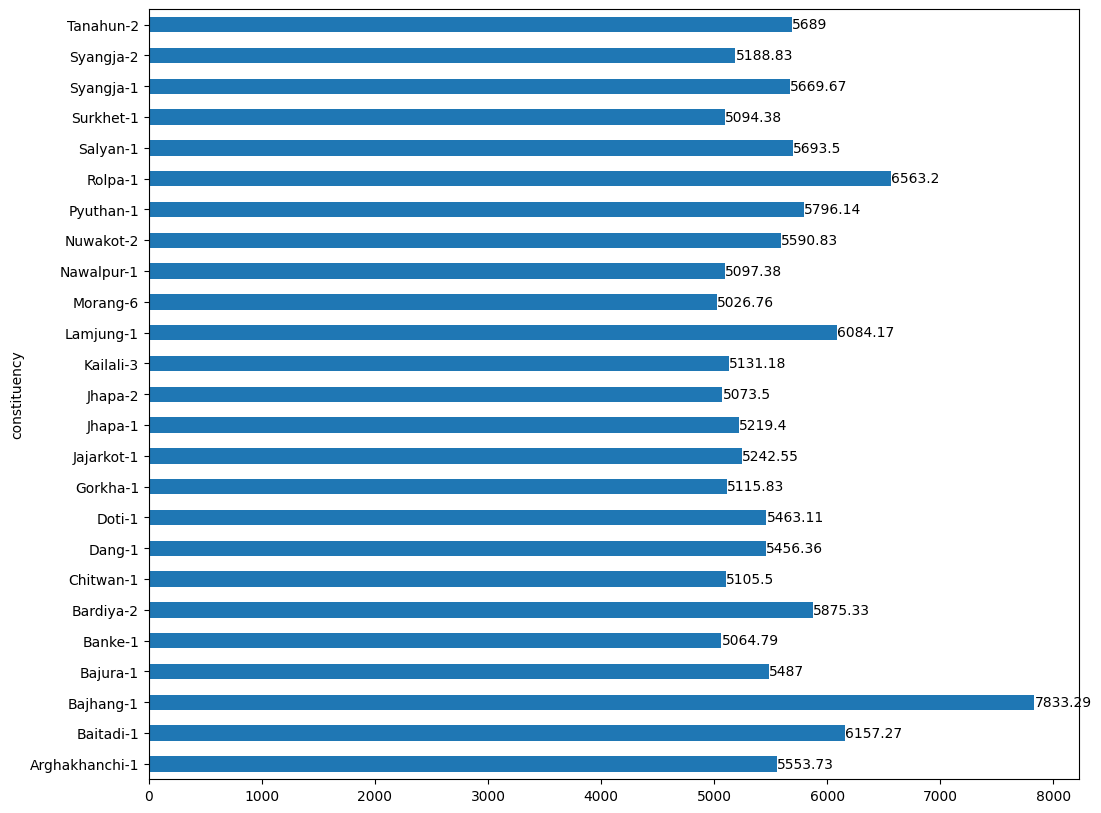

In [121]:
# 1. Assign the plot to 'ax'
ax = temp_seri.plot(kind='barh', fontsize=10, figsize=(12, 10))

# 2. Use the first container from the plot
plt.bar_label(container=ax.containers[0])

plt.show()

In [122]:
ax.containers[0]

<BarContainer object of 25 artists>

- ***Bajhang-1** has the highest average vote count (**7,833.29**), followed by **Rolpa-1** (**6,563.20**) and **Baitadi-1** (**6,157.27**).*


### `votes` ↔ `province` (num-cat)

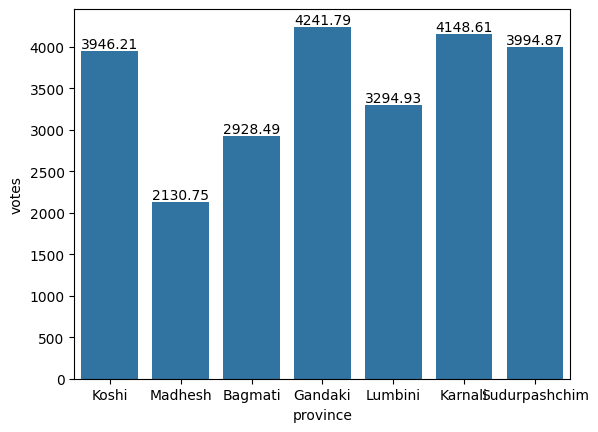

In [123]:
ax = sns.barplot(data=df, x='province', y='votes', estimator='mean', errorbar=None)
ax.bar_label(ax.containers[0], fontsize=10)

plt.show()

### `votes` ↔ `district` (num-cat)

In [124]:
temp_seri = df.pivot_table(values='votes', index='district', aggfunc='mean')['votes']
temp_seri

district
Achham          3583.352941
Arghakhanchi    5553.733333
Baglung         3986.391304
Baitadi         6157.272727
Bajhang         7833.285714
                   ...     
Syangja         5429.250000
Tanahun         4740.666667
Taplejung       3299.769231
Tehrathum       3066.250000
Udayapur        3699.096774
Name: votes, Length: 77, dtype: float64

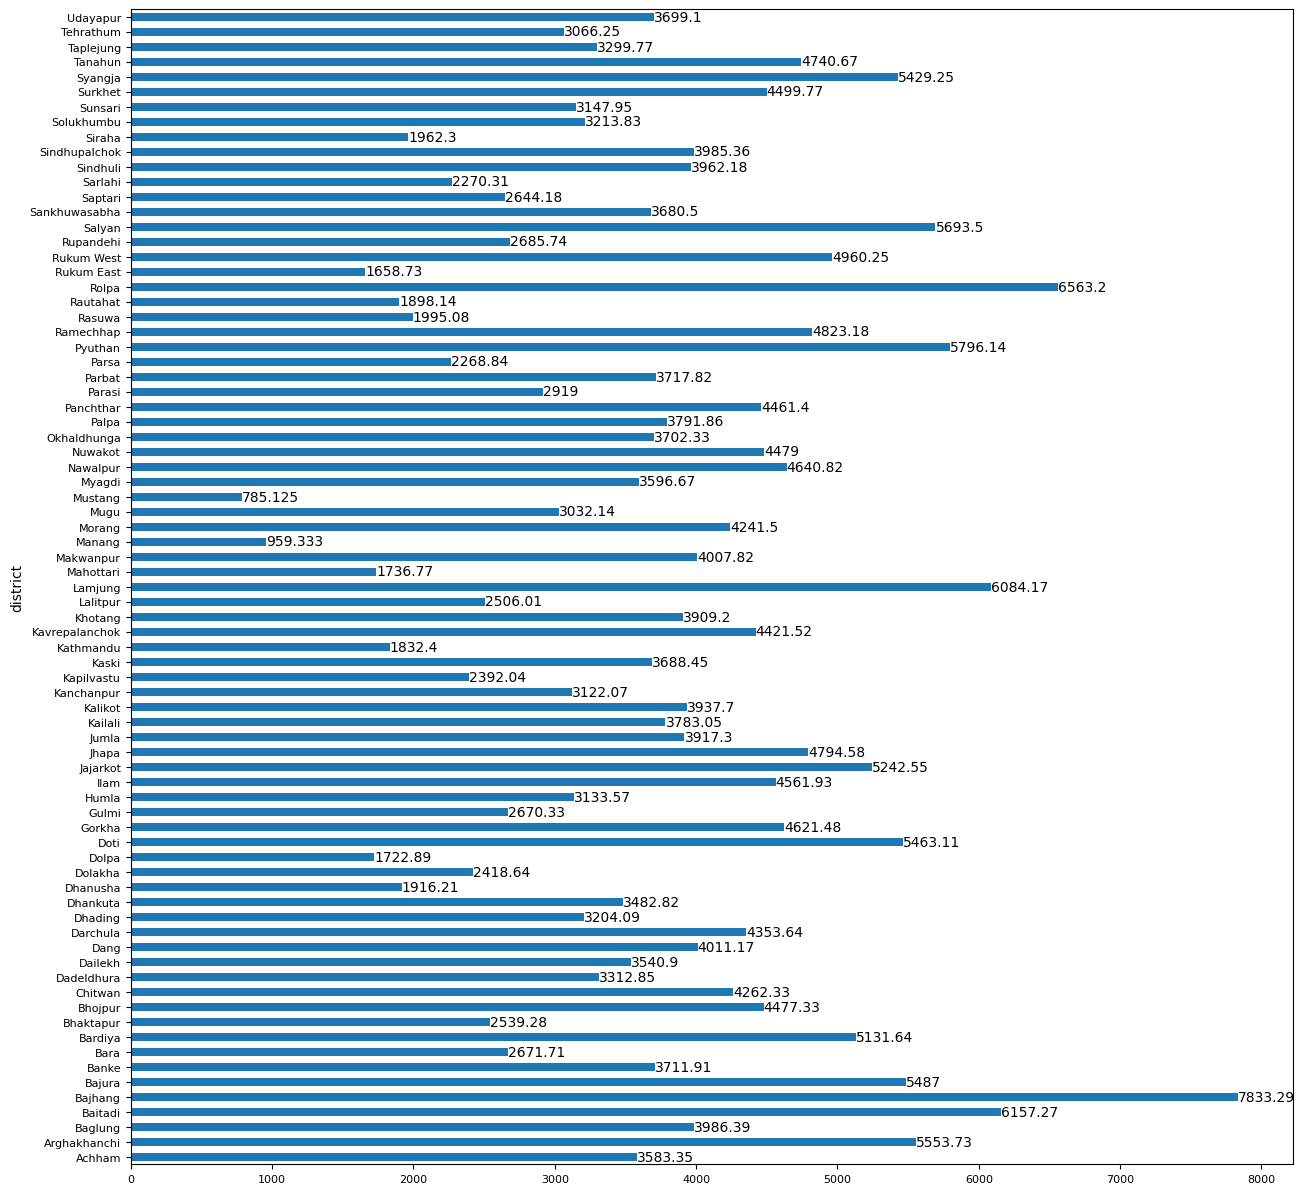

In [125]:
ax = temp_seri.plot(kind='barh', fontsize=8, figsize=(15,15))
ax.bar_label(ax.containers[0])

plt.show()

- *Among all districts, **Bajhang** records the highest average vote count (**7,833.29**), whereas **Mustang** records the lowest (**785.13**).*

### `votes` ↔ `address` (num-cat)

In [126]:
df['address'].value_counts()

address
Kathmandu                                                                 121
Rupandehi                                                                  83
Mahottari                                                                  77
Siraha                                                                     76
Sarlahi                                                                    71
                                                                         ... 
Nawalparasi (Bardghat Susta West) Ramgram Municipality Piprahiya            1
Nawalparasi (Bardghat Susta West) Sunwal Municipality Sundarvasti           1
Navalparasi (Bardghat Susta West) Palhinandan Rural Municipality Palhi      1
Nawalparasi (Bardghat Susta West) Sunwal Municipality Mangalnagar           1
Jhapa Mechinagar Municipality Ward Khal                                     1
Name: count, Length: 1426, dtype: int64

> ***Note:** To improve the clarity of the analysis, only **addresses associated with winning candidates** are considered when calculating the average vote count.*

In [127]:
temp_seri = df.query('is_winner == True').pivot_table(values='votes', index='address', aggfunc='mean')['votes']
temp_seri

address
Acham                                               10138.5
Arghakhanchi                                        35023.0
Baglung                                             16787.0
Baitadi                                             22134.0
Baitadi Melauli Municipality Khaligad               31953.0
                                                     ...   
Syangja                                             27212.5
Tanahun Bhanu Municipality                          32687.0
Taplejung Sirijungha Rural Municipality Madibung    13962.0
Tehrathum Myanglung Municipality Campus Tol         11561.0
Udaipur                                             14802.0
Name: votes, Length: 124, dtype: float64

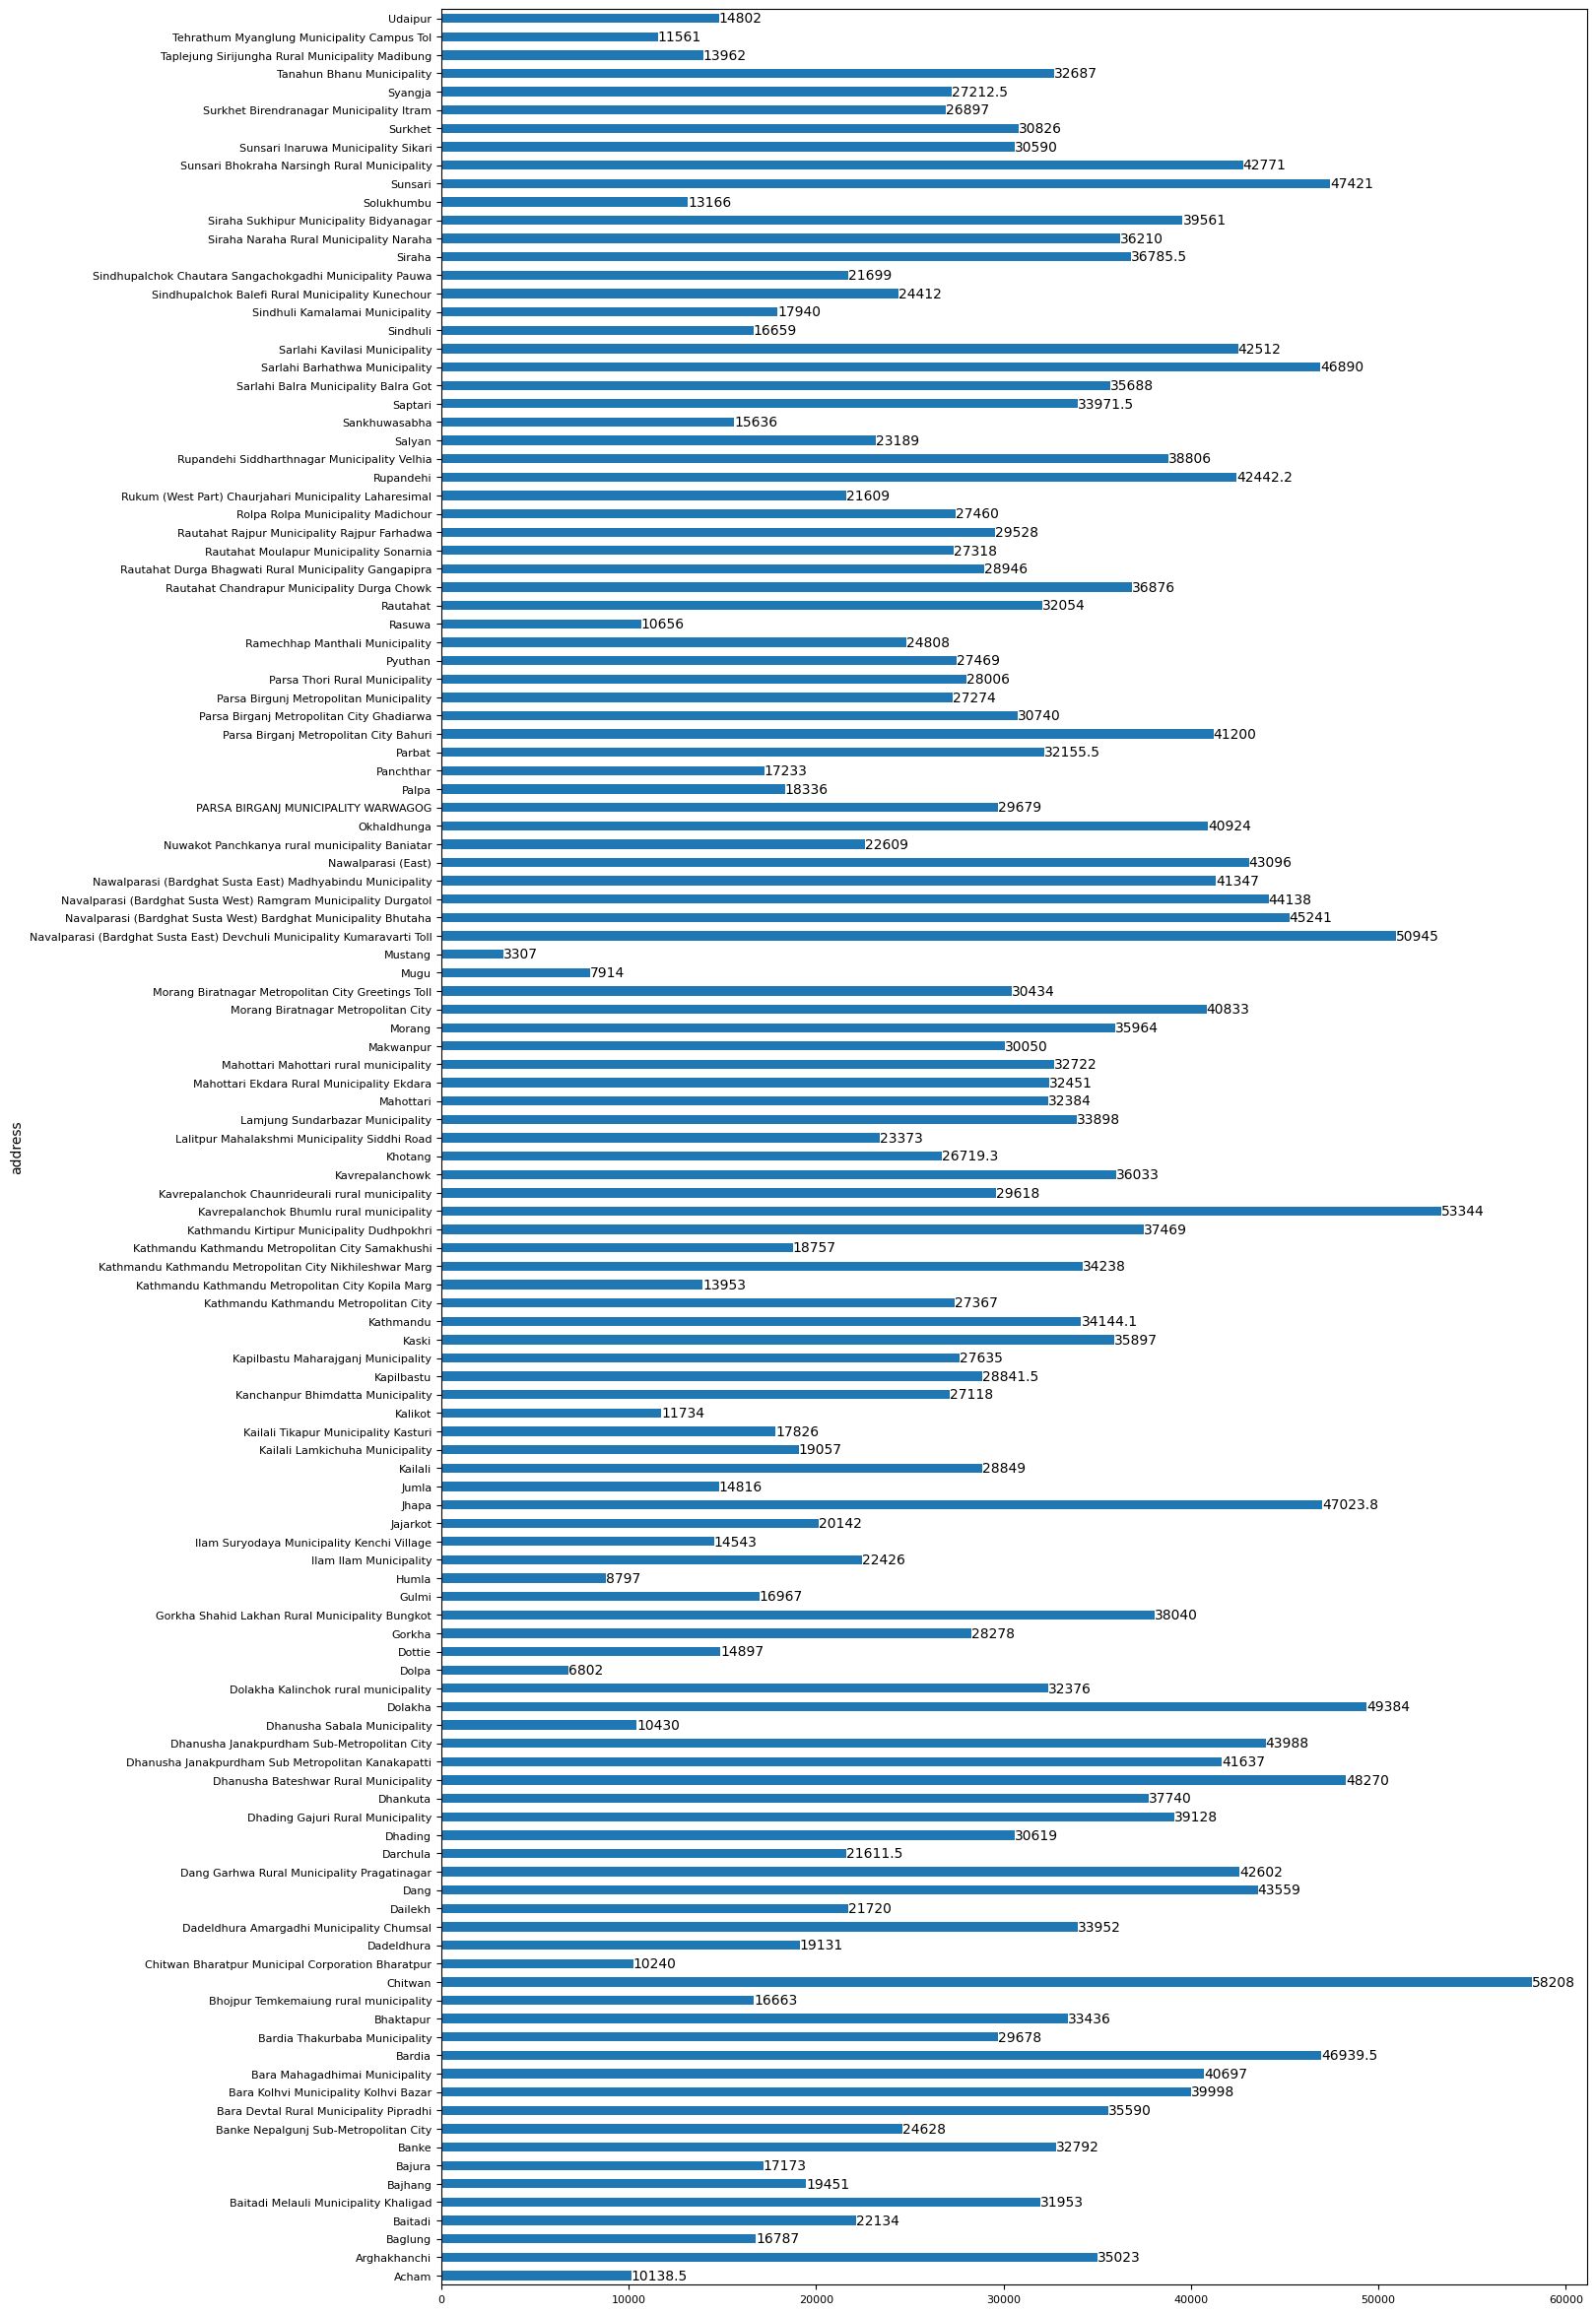

In [128]:
ax = temp_seri.plot(kind='barh', fontsize=8, figsize=(15,30))
ax.bar_label(ax.containers[0])

plt.show()

- ***Chitwan** has the highest average vote count (**58,208**) among the **living addresses of winning candidates**, suggesting that winners residing in Chitwan received the strongest average electoral support.*

- ***Bhumlu Rural Municipality of Kavrepalanchok** records the second-highest average vote count, with an average of **53,344 votes**.*

- *In contrast, **Mustang** recorded the lowest average vote count for winning candidates, with an average of **3,307 votes**. This suggests that candidates in Mustang required fewer votes on average to win compared to candidates from other areas.*

### `votes` ↔ `is_winner` (num-cat)

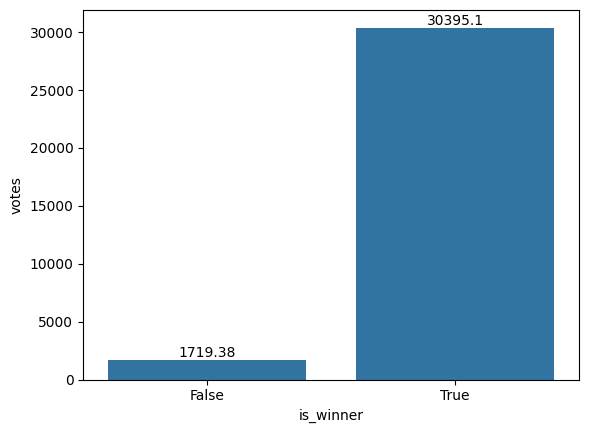

In [129]:
ax = sns.barplot(data=df, x='is_winner', y='votes', errorbar=None)
ax.bar_label(container=ax.containers[0])

plt.show()

- *The analysis shows a substantial gap in average votes between winners and non-winners. **Winning candidates** received approximately **30,395 votes on average**, compared to only **1,719 votes** for **non-winning candidates**.*

<Axes: xlabel='votes', ylabel='Density'>

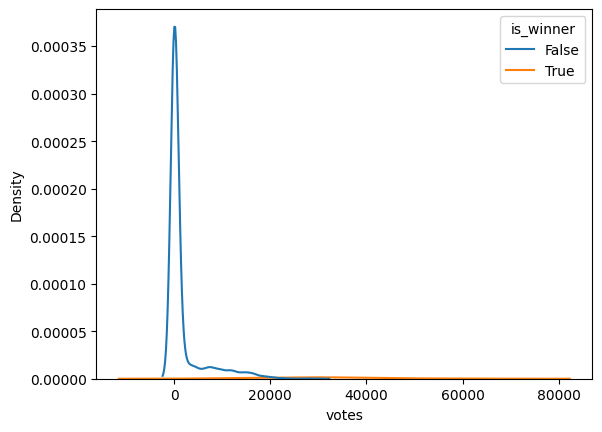

In [130]:
sns.kdeplot(data=df, x='votes', hue='is_winner')

- *The vote distribution is heavily **right-skewed**, with most candidates receiving fewer votes and only a small number of candidates achieving very high vote counts.*

## 4. **Multivariate analysis**

In [131]:
temp_df = df[['age','votes','votes_cast','total_voters']].corr()
temp_df

,age,votes,votes_cast,total_voters
age,1.000000,0.066515,-0.012486,-0.000086
votes,0.066515,1.000000,0.043219,0.075333
votes_cast,-0.012486,0.043219,1.000000,0.875233
total_voters,-0.000086,0.075333,0.875233,1.000000


<Axes: >

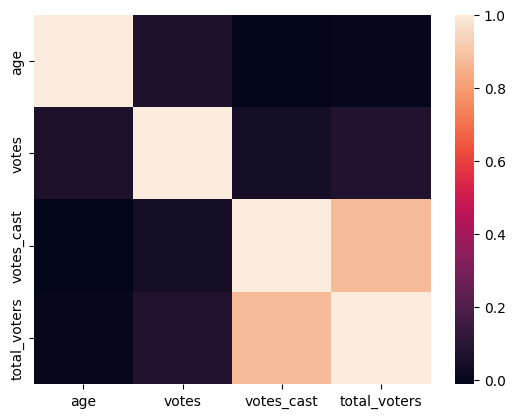

In [132]:
sns.heatmap(temp_df)

In [133]:
temp_df['votes']

age             0.066515
votes           1.000000
votes_cast      0.043219
total_voters    0.075333
Name: votes, dtype: float64

- *There is a weak positive connection between **age, votes, votes_cast, and total_voters**. Candidates in areas with more voters may receive slightly higher votes, but these variables alone do not decide the election result. Factors like **party support, candidate image, and campaign activities** also influence the outcome.*

## 5. **Feature engineering**

> The `invalid_votes` column was created by subtracting valid `votes` from total `votes_cast`. It helps analyze the number of rejected ballots in each constituency and identify areas with higher rates of invalid voting.

In [134]:
groups = df.groupby(by='constituency')[['votes','votes_cast']]

In [135]:
groups.size()

constituency
Achham-1           8
Achham-2           9
Arghakhanchi-1    15
Baglung-1         11
Baglung-2         12
                  ..
Tanahun-2         11
Taplejung-1       13
Tehrathum-1       12
Udayapur-1        18
Udayapur-2        13
Length: 165, dtype: int64

In [136]:
def rejected_ballots(group):
    group['invalid_votes'] = group['votes_cast'] - group['votes'].sum()
    return group

In [137]:
temp_df = groups.apply(rejected_ballots)
temp_df

votes  votes_cast  invalid_votes
constituency                                       
Achham-1     3141  10759       30348              0
             3142  10233       30348              0
             3143   7389       30348              0
             3144   1739       30348              0
             3145    102       30348              0
...                  ...         ...            ...
Udayapur-2   490     152       40756              0
             491     103       40756              0
             492      90       40756              0
             493      85       40756              0
             494      40       40756              0

[3406 rows x 3 columns]

In [138]:
temp_df['invalid_votes'].describe()

count    3406.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: invalid_votes, dtype: float64

- *The comparison between `votes_cast` and `votes` indicates that all cast ballots were counted as valid votes. Therefore, the `invalid_votes` feature contains zero values, suggesting no recorded ballot rejections in the available election data.*

In [139]:
temp_df.tail(13)

votes  votes_cast  invalid_votes
constituency                                      
Udayapur-2   482  14802       40756              0
             483   7648       40756              0
             484   7290       40756              0
             485   5197       40756              0
             486   4139       40756              0
             487    607       40756              0
             488    383       40756              0
             489    220       40756              0
             490    152       40756              0
             491    103       40756              0
             492     90       40756              0
             493     85       40756              0
             494     40       40756              0

In [140]:
groups.get_group(name='Udayapur-2')['votes'].sum()

np.int64(40756)

> Creating a feature called `abstained_voters` by subtracting `votes_cast` from `total_voters` which shows the number of eligible voters who did not vote and helps identify constituencies with lower voter participation.

In [141]:
df['abstained_voters'] = df['total_voters'] - df['votes_cast']

In [142]:
# Select 1st row from each groups/constituencies
temp_df = df.groupby(by='constituency', as_index=False)[['constituency','abstained_voters','total_voters']].head(1)
temp_df

,constituency,abstained_voters,total_voters
0,Taplejung-1,47411,90308
13,Panchthar-1,76437,143358
28,Ilam-1,52905,112296
41,Ilam-2,55694,119475
55,Jhapa-1,52702,130993
...,...,...,...
3303,Kanchanpur-2,48455,109572
3322,Kanchanpur-3,49541,103087
3339,Parasi-1,45983,123072
3365,Parasi-2,47593,131049


In [143]:
def voter_abstention(row):
    row['abstention_rate'] = np.round(a=(row['abstained_voters'] / row['total_voters']) * 100, decimals=1)
    return row

In [144]:
temp_df = temp_df.apply(voter_abstention, axis=1)
temp_df

,constituency,abstained_voters,total_voters,abstention_rate
0,Taplejung-1,47411,90308,52.5
13,Panchthar-1,76437,143358,53.3
28,Ilam-1,52905,112296,47.1
41,Ilam-2,55694,119475,46.6
55,Jhapa-1,52702,130993,40.2
...,...,...,...,...
3303,Kanchanpur-2,48455,109572,44.2
3322,Kanchanpur-3,49541,103087,48.1
3339,Parasi-1,45983,123072,37.4
3365,Parasi-2,47593,131049,36.3


In [145]:
# Select top 10 constituencies with high abstention_rate
temp_seri = temp_df.sort_values(by='abstention_rate', ascending=False).set_index('constituency')['abstention_rate'].head(10)
temp_seri

constituency
Rukum East-1    82.9
Achham-1        63.2
Achham-2        63.1
Doti-1          61.7
Khotang-1       60.0
Manang-1        58.9
Udayapur-2      57.6
Bhojpur-1       57.3
Bajhang-1       56.8
Baitadi-1       56.7
Name: abstention_rate, dtype: float64

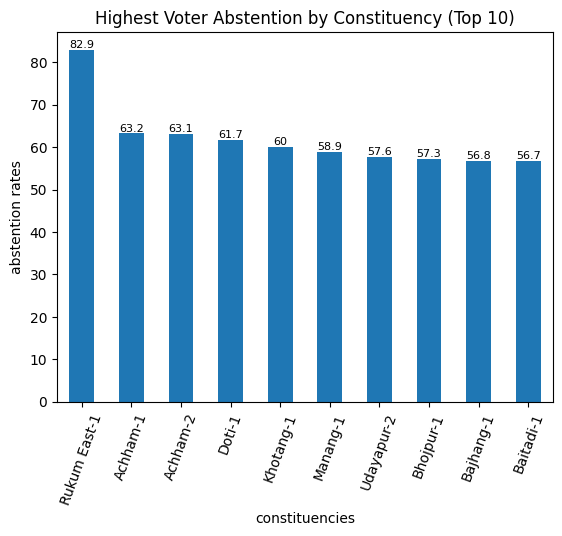

In [146]:
ax = temp_seri.plot(kind='bar', rot=70)
plt.bar_label(ax.containers[0], fontsize=8)

plt.ylabel('abstention rates')
plt.xlabel('constituencies')
plt.title("Highest Voter Abstention by Constituency (Top 10)")

plt.show()

- *Rukum East-1 shows the highest voter abstention rate, where around **88,404 registered voters did not cast their ballots**. With only **18,246 votes cast from 106,650 registered voters**, the constituency had a notably low voter participation level.*

In [147]:
print("Total voter abstention =", str(round(number=(1 - df['votes_cast'].sum() / df['total_voters'].sum()) * 100, ndigits=1)) + " %")

Total voter abstention = 42.4 %


In [148]:
df.query("constituency == 'Rukum East-1'")[['candidate','party','education_category','votes','votes_cast','abstained_voters','total_voters']]

,candidate,party,education_category,votes,votes_cast,abstained_voters,total_voters
2827,Pushpa Kamala Dahala Prachand,Nepali Communist Party,Bachelor's Degree,10240,18246,88404,106650
2828,Lilamani Gautam,Nepal Communist Party (Ekikrit Marxbadi Leninb...,Master's Degree,3462,18246,88404,106650
2829,Kusuma Devi Thapa,Nepali Congress,Master's Degree,3081,18246,88404,106650
2830,Lakhana Kumara Thapa,Rastriya Swatantra Party,Basic Education (Up to Grade 8),819,18246,88404,106650
2831,Sandipa Pun,Pragatishil Loktantrik Party,Bachelor's Degree,203,18246,88404,106650
2832,Juddha Bahadura Budha Magar,Nepal Communist Party (Maoist),Secondary Education (Grade 9-10 / SLC / SEE),191,18246,88404,106650
2833,Roshana Shah,Rastriya Prajatantra Party,Higher Secondary / Intermediate (10+2 / PCL),82,18246,88404,106650
2834,Jyoti Roka Magar,Mongol National Organization,Literate / Non-Formal,55,18246,88404,106650
2835,Dharma Kumara Budha,National Republic Nepal,Bachelor's Degree,51,18246,88404,106650
2836,Chandra Prasada Shahi,Rastriya Janamorcha,Basic Education (Up to Grade 8),32,18246,88404,106650


# ***My opinion***

> *From my perspective, electoral outcomes are shaped by many external factors, including **candidate popularity**, **social influence**, **voter relationships**, and **party-level campaign strategies**. Since these variables are not available in the dataset, the analysis only captures limited candidate characteristics, such as candidate qualifications (**education_category**) and residential background (**address**), which may serve as indirect indicators for understanding candidate profiles and potential electoral patterns.*